<a href="https://colab.research.google.com/github/kittiporntum1-cell/ADALL_github/blob/main/Tum_Co_pilot_guidance__Copy_of_ADALL_Practical_Test_Revision_Regression_vold2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Practical Test Revision (Regression): Predicting Number of Failed Subjects

This notebook revises a **regression workflow** using a target that is a **special case**:

- Your target is a **count**: number of subjects failed (based on scores below **10** from **G1, G2, G3**).
- Because the target is an **integer count** (often 0, 1, 2, 3), it can *feel* similar to classification.
- However, you are still doing **regression** because the model outputs a **numeric value** and you evaluate using **regression metrics**.

## How to think about this target (important for revision)

| Perspective | What it means here | Typical choice |
|---|---|---|
| Regression view | Predict a numeric count (can be 0–3, but model can output non-integers) | MSE / MAE / RMSE, R² |
| Classification-like view (edge case) | If you convert counts into categories (e.g., 0 vs ≥1) you can classify | Accuracy, F1, ROC-AUC |

### Caveat you must remember
Even when the target behaves like classes, **do not switch to classification** unless the task explicitly asks you to do so.

## Practical test habits
- Keep code **readable** and **step-by-step**.
- Add short notes explaining **why** a step is needed.
- When unsure: print shapes, check missing values, and check your target distribution.

---


STEP 0  Setup

STEP 1  Load Data

STEP 2  Explore Dataset
         df.shape
         df.info()
         df.describe()
         df.isnull().sum()

STEP 3  Dataset Profile
    dataset_profile

Markdown:
    - What the dataset is about
    - Target definition
    - Dataset imbalance
    - Evaluation metric choice

STEP 3A LLM Dataset Reasoning Prompt

STEP 4  LLM assisted problem framing

STEP 5  Context

STEP 6  Instruction

STEP 7  Payload

STEP 8  OpenAI Recommendations

STEP 9  Review Recommendations

STEP 10  Data Cleaning
         - Missing values
         - Duplicates
         - Invalid values
         - Data types
         - Remove leakage columns (if instructed)

STEP 11 Create Target
          y = target

STEP 12 Jitter Plots (Predictor vs Target Analysis)


STEP 13  Train/Test Split

STEP 14 Preprocessing
          - Encoding
          - Scaling
          - ColumnTransformer
          - Pipeline

STEP 15 Baseline Model

STEP 16 Evaluation
          - MAE
          - RMSE
          - R²

STEP 17 Improvements
          - Hyperparameter tuning
          - Feature engineering
          - Compare models

## **Step 0) Setup**

In [4]:
# Core libraries

import os
import shutil
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Modelling libraries used later in Session 2
from sklearn.model_selection import train_test_split, ShuffleSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Make wide tables easier to read in Colab
pd.set_option('display.max_columns', 100)

# **Step 0A: OpenAI Setup**

In [5]:
from google.colab import userdata
from openai import OpenAI

# load key from Colab Secrets
api_key = userdata.get('OPENAI_API_KEY')

client = OpenAI(
    api_key=api_key
)
print("OpenAI client created successfully.")

OpenAI client created successfully.



#**#Step 1) Load data and do quick checks**

**Goal:** confirm you loaded the correct file, and the dataset looks sensible.

Checklist:
- Use `df.head()` to sanity check columns.
- Use `df.shape` to confirm rows and columns.
- Use `df.info()` to see dtypes and missing values quickly.

If anything looks odd (unexpected columns, too few rows), stop and fix it before modelling.


In [ ]:
# another load dataset template (github)

github_raw_url = 'https://raw.githubusercontent.com/rq-goh/ADALL_github/refs/heads/main/laptop_prices_2024_sgd_TL.csv'

df = pd.read_csv(github_raw_url)

print('Dataset loaded successfully.')
print('Shape:', df.shape)
display(df.head())

In [6]:
# ------------------------------------------------------------
# LOAD DATA (do first) , Template for Kagglehub data set
# Tip: if this block is slow, run it early.
# ------------------------------------------------------------

import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("devansodariya/student-performance-data")
print("Downloaded to:", path)
print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "student_data.csv"))
df.head()

100%|██████████| 7.16k/7.16k [00:00<00:00, 14.1MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/devansodariya/student-performance-data/versions/1
['student_data.csv']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [ ]:
# another load dataset template (csv file)
df = pd.read_csv(...)
print(df.shape)
display(df.head())

# **Step 2: Understand Dataset**

In [4]:
df = pd.read_csv(os.path.join(path, "student_data.csv"))
df.shape # Number of rows & columns

(395, 33)

In [5]:
df.info() #dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [6]:
df.describe(include='all')

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395,395,395.000000,395,395,395,395.000000,395.000000,395,395,395,395,395.000000,395.000000,395.000000,395,395,395,395,395,395,395,395,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
unique,2,2,NaN,2,2,2,NaN,NaN,5,5,4,3,NaN,NaN,NaN,2,2,2,2,2,2,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,GP,F,NaN,U,GT3,T,NaN,NaN,other,other,course,mother,NaN,NaN,NaN,no,yes,no,yes,yes,yes,yes,no,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,349,208,NaN,307,281,354,NaN,NaN,141,217,145,273,NaN,NaN,NaN,344,242,214,201,314,375,329,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,16.696203,NaN,NaN,NaN,2.749367,2.521519,NaN,NaN,NaN,NaN,1.448101,2.035443,0.334177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,NaN,NaN,1.276043,NaN,NaN,NaN,1.094735,1.088201,NaN,NaN,NaN,NaN,0.697505,0.839240,0.743651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,NaN,NaN,15.000000,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,NaN,NaN,16.000000,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,NaN,NaN,17.000000,NaN,NaN,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,1.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,NaN,NaN,18.000000,NaN,NaN,NaN,4.000000,3.000000,NaN,NaN,NaN,NaN,2.000000,2.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000


In [7]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [8]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

### What you should write in markdown as you go

In a practical test, you are often graded on your reasoning, not just your code.

As you proceed, add short notes like:
- What does each key column represent in plain words?
- What is your target, and why is it defined this way?
- Is the dataset imbalanced? If yes, what is the impact on evaluation?
- What metric did you choose, and why?

Keep each explanation to **2 to 5 lines**.


###Info about the dataset:

Student Performance Data was obtained in a survey of students' math course in secondary school.
It consists of 33 Column
Dataset Contains Features like:
```
school ID
gender
age
size of family
Father education
Mother education
Occupation of Father and Mother
Family Relation
Health
Grades
```

# **Step 3: Create Dataset Profile**  (Template to be re-used)

In [7]:
dataset_profile = f"""
Dataset Shape:
{df.shape}

Columns:
{list(df.columns)}

Data Types:
{df.dtypes.to_string()}

Missing Values:
{df.isnull().sum().to_string()}

Duplicate Rows:
{df.duplicated().sum()}

Sample Records:
{df.head().to_string()}
"""

print(dataset_profile)


Dataset Shape:
(395, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences      

# **Short Text (Use in practical test)**: Explanation: A text-based dataset profile was created to summarise the dataset structure, size, columns, data types, missing values, duplicate records and sample observations. This provides a concise overview of the dataset before machine learning modelling.


In [ ]:
# Mr.Zaw payload template ####
# Build payload text step by step.
# Payload text is a short profile of the dataset.
# It is safer and smaller than sending the full dataset to the LLM.

payload_text = ''

# 1. Shape
payload_text += '=== SHAPE ===\n'
payload_text += 'Rows: ' + str(df.shape[0]) + '\n'
payload_text += 'Columns: ' + str(df.shape[1]) + '\n\n'

# 2. Column names and data types
payload_text += '=== COLUMNS AND DATA TYPES ===\n'
payload_text += df.dtypes.to_string()
payload_text += '\n\n'

# 3. Numeric summary
payload_text += '=== NUMERIC SUMMARY ===\n'
numeric_summary = df.describe(include='number').round(2)
payload_text += numeric_summary.to_string()
payload_text += '\n\n'

# 4. Missing values
payload_text += '=== MISSING VALUES ===\n'
missing_table = pd.DataFrame()
missing_table['missing_count'] = df.isna().sum()
missing_table['missing_pct'] = (df.isna().sum() / len(df) * 100).round(2)
payload_text += missing_table.to_string()
payload_text += '\n\n'

# 5. Unique values per column
payload_text += '=== UNIQUE VALUES PER COLUMN ===\n'
unique_table = pd.DataFrame()
unique_table['unique_count'] = df.nunique(dropna=False)
payload_text += unique_table.to_string()
payload_text += '\n\n'

# 6. Correlation between numeric columns
payload_text += '=== CORRELATION BETWEEN NUMERIC COLUMNS ===\n'
correlation_table = df.corr(numeric_only=True).round(2)
payload_text += correlation_table.to_string()
payload_text += '\n\n'

# 7. Top 10 values for categorical columns
payload_text += '=== TOP 10 VALUES FOR CATEGORICAL COLUMNS ===\n'

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_columns) == 0:
    payload_text += 'No categorical columns found.\n'
else:
    for col in categorical_columns:
        payload_text += '\nColumn: ' + col + '\n'
        payload_text += df[col].value_counts(dropna=False).head(10).to_string()
        payload_text += '\n'

payload_text += '\n'

# 8. Simple warning checks
payload_text += '=== SIMPLE WARNING CHECKS ===\n'

id_like_columns = []
constant_columns = []

for col in df.columns:
    unique_count = df[col].nunique(dropna=False)

    if unique_count == len(df):
        id_like_columns.append(col)

    if unique_count <= 1:
        constant_columns.append(col)

payload_text += 'Possible ID-like columns: ' + str(id_like_columns) + '\n'
payload_text += 'Constant columns: ' + str(constant_columns) + '\n'
payload_text += 'Duplicate rows: ' + str(df.duplicated().sum()) + '\n'

print(payload_text)

# This cell builds a short dataset profile called payload_text.
# Instead of sending the full dataset to the LLM, we send summary information only.
# The payload includes shape, column types, numeric summary, missing values, unique counts, correlations, and common category values.
# It also adds simple warning checks for possible ID-like columns, constant columns, and duplicate rows.
# This helps the LLM comment on data readiness without needing every row of the dataset.

=== SHAPE ===
Rows: 395
Columns: 33

=== COLUMNS AND DATA TYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== NUMERIC SUMMARY ===
          age    Medu    Fedu  traveltime  studytime  failures  famrel  freetime   goout    Dalc    Walc  health  absences      G1      G2      G3
count  395.00  395.00  395.00      395.00     395.00    395.00  395

In [8]:
# Tum payload template  ******* Use this **********************
from io import StringIO

# ==========================================
# CHANGE ONLY THIS LINE
# ==========================================

target_column = None

# Example when target is known:
# target_column = "Price"

# ==========================================

buffer = StringIO()

# DATA TYPES
buffer.write("=== DATA TYPES ===\n")
buffer.write(df.dtypes.to_string())
buffer.write("\n\n")

# SHAPE
buffer.write("=== DATASET SHAPE ===\n")
buffer.write(f"Rows: {df.shape[0]}\n")
buffer.write(f"Columns: {df.shape[1]}\n\n")

# TARGET
buffer.write("=== TARGET COLUMN ===\n")

if target_column is None:
    buffer.write("Target not yet specified.\n")
else:
    buffer.write(f"Target: {target_column}\n")

    if target_column in df.columns:
        buffer.write(f"Data Type: {df[target_column].dtype}\n")
        buffer.write(
            f"Unique Values: {df[target_column].nunique(dropna=False)}\n"
        )

buffer.write("\n")

# MISSING VALUES
buffer.write("=== MISSING VALUES ===\n")

missing_summary = (
    df.isna()
      .sum()
      .to_frame("missing_count")
      .assign(
          missing_pct=lambda x:
          (x["missing_count"] / len(df) * 100).round(2)
      )
)

buffer.write(missing_summary.to_string())
buffer.write("\n\n")

# DUPLICATES
buffer.write("=== DUPLICATE ROWS ===\n")
buffer.write(str(df.duplicated().sum()))
buffer.write("\n\n")

# NUMERIC SUMMARY
buffer.write("=== NUMERIC SUMMARY ===\n")

try:
    buffer.write(
        df.describe(include="number")
          .round(3)
          .to_string()
    )
except:
    buffer.write("No numeric columns.")

buffer.write("\n\n")

# CATEGORICAL SUMMARY
buffer.write("=== CATEGORICAL SUMMARY ===\n")

try:
    buffer.write(
        df.describe(include=["object","category"])
          .to_string()
    )
except:
    buffer.write("No categorical columns.")

buffer.write("\n\n")

# UNIQUE VALUES
buffer.write("=== UNIQUE VALUES PER COLUMN ===\n")

buffer.write(
    df.nunique(dropna=False)
      .to_frame("unique_count")
      .to_string()
)

buffer.write("\n\n")

# CONSTANT COLUMNS
buffer.write("=== CONSTANT COLUMNS ===\n")

constant_cols = list(
    df.columns[
        df.nunique(dropna=False) <= 1
    ]
)

buffer.write(str(constant_cols))
buffer.write("\n\n")

# POTENTIAL ID COLUMNS
buffer.write("=== POTENTIAL ID COLUMNS ===\n")

id_cols = list(
    df.columns[
        df.nunique(dropna=False) == len(df)
    ]
)

buffer.write(str(id_cols))
buffer.write("\n\n")

# CORRELATION
buffer.write("=== CORRELATION MATRIX ===\n")

try:

    corr_matrix = (
        df.corr(numeric_only=True)
          .round(3)
    )

    if len(corr_matrix) > 0:
        buffer.write(corr_matrix.to_string())
    else:
        buffer.write("No numeric columns available.")

except Exception as e:
    buffer.write(str(e))

buffer.write("\n\n")

# TOP CATEGORICAL VALUES
buffer.write("=== TOP VALUES FOR CATEGORICAL COLUMNS ===\n")

cat_cols = df.select_dtypes(
    include=["object","category"]
).columns

if len(cat_cols) == 0:
    buffer.write("No categorical columns found.\n")

else:

    for col in cat_cols:

        buffer.write(f"\nColumn: {col}\n")

        buffer.write(
            df[col]
              .value_counts(dropna=False)
              .head(10)
              .to_string()
        )

        buffer.write("\n")

buffer.write("\n")

# SAMPLE ROWS
buffer.write("=== SAMPLE ROWS ===\n")
buffer.write(df.head().to_string())

payload_text = buffer.getvalue()

print(payload_text)

=== DATA TYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64

=== DATASET SHAPE ===
Rows: 395
Columns: 33

=== TARGET COLUMN ===
Target not yet specified.

=== MISSING VALUES ===
            missing_count  missing_pct
school                  0          0.0
sex                     0          0.0
age                     0          0.0
address       


Dataset profile (no charts yet)

**Why this matters:** In a practical test, you should be able to describe your dataset without relying on charts.

Focus on:
- which columns are numeric vs categorical,
- missing values (how many, where),
- target column (what type it is, what values it takes).

Write your observations as short bullet points in your report.


###Mock question (revision of steps you have already practised)

1. Create a text-based payload that clearly describes the dataset.
The description should summarise the dataset structure, key columns, size, and any notable data issues.

2. Then, send this payload to the OpenAI API together with:

>>clear context about the task, and
>>
>>a concise instruction telling the model what you want it to do with the dataset information.

The following block shows an example in image form for revision purposes.

# **Step3 (A): LLM Dataset Reasoning Prompt**

Can skip this step if no need.

In [11]:
# Universal dataset / Business explanation prompt  **** Lastest ******

reasoning_prompt = f"""
You are a senior data scientist preparing answers for a data analytics practical test.

DATASET PROFILE:

{payload_text}

TASK:

Analyse the dataset and provide concise practical-test answers.

Provide:

1. Dataset Overview
   - What the dataset appears to contain
   - Business context

2. Key Columns
   - Important numeric columns
   - Important categorical columns

3. Target Analysis

If a target column is already provided in the dataset profile:
- Explain the target
- State whether it is numeric or categorical
- State whether the problem is Regression or Classification

If the target is not provided:
- Recommend the most likely target variable
- Explain why

If a new target may need to be created:
- Suggest the target definition
- Explain how it should be created
- Identify any leakage risks

4. Modelling Considerations
   - Regression or Classification
   - Evaluation metric
   - Balanced or imbalanced target risk

5. Data Quality Summary
   - Missing values
   - Duplicate rows
   - Outliers
   - Possible ID columns
   - Leakage concerns
   - Other data-quality risks

6. Business Perspective
   - Main stakeholders
   - Business value
   - Risks

Requirements:

- Use markdown format.
- Use concise practical-test language.
- Use numbered sections.
- Avoid jargon where possible.
- Suitable for lecturer marking.
"""

reasoning_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are helping a student prepare concise markdown observations for a data analytics practical test.

    Keep the answers short, practical and easy for a lecturer to mark.

    Do not provide multiple alternatives.
    Choose the most likely answer.
    """,
    input=reasoning_prompt
)

print(reasoning_response.output_text)

## 1. Dataset Overview
1. **What it contains:** Student background and school-life features, including demographics (age, sex), family context (family size, parents’ education/work, guardian), study habits (studytime, failures), support flags (schoolsup, famsup, paid, nursery, higher, internet), and lifestyle (activities, romantic, alcohol use Dalc/Walc, health, absences).
2. **Likely business context:** **Predict student academic performance** (grades) to support early intervention (tutoring/support, monitoring attendance, study support).

## 2. Key Columns
1. **Important numeric columns (strong for modelling):**
   - **Grades:** `G1`, `G2`, `G3` (target candidates; see below)
   - **Study/behavior:** `studytime`, `failures`, `absences`
   - **Lifestyle:** `Dalc`, `Walc`, `goout`, `health`, `freetime`
   - **Family relationship:** `famrel`
   - **Travel/attendance proxies:** `traveltime`
2. **Important categorical columns:**
   - **School & demographics:** `school`, `sex`, `address`
 

In [12]:
# LLM Dataset Reasoning Prompt1 (Back up:Can skip this step if no need)

reasoning_prompt = f"""
You are a senior data scientist preparing a practical-test report.

Dataset Profile:

{payload_text}

Please provide concise reasoning suitable for a markdown report.

Answer the following:

1. What does this dataset appear to contain?

2. Explain the key columns in plain business language.

3. What is the most likely target variable?
   - Explain why.
   - State whether the target is numeric or categorical.

4. Is the target likely to be balanced or imbalanced?
   - Explain the possible impact on model evaluation.

5. Is this likely to be a Regression or Classification problem?
   - Explain why.

6. Which evaluation metric(s) would be appropriate?
   - Explain why.

7. Summarise:
   - Numeric columns
   - Categorical columns
   - Missing values
   - Potential data-quality issues

Requirements:

- Keep each answer between 2 and 5 lines.
- Use practical business language.
- Use markdown bullet points.
- Avoid technical jargon where possible.
- Be suitable for a practical-test submission.
"""

reasoning_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are helping a student prepare concise markdown observations for a data analytics practical test.

    Keep the answers short, practical and easy for a lecturer to mark.

    Do not provide multiple alternatives.
    Choose the most likely answer.
    """,
    input=reasoning_prompt
)

print(reasoning_response.output_text)

- **1) What does this dataset appear to contain?**  
  - Student-level records for secondary school learners (395 rows, 33 columns).  
  - Includes demographics, family background, study habits, and school/assessment performance scores.  

- **2) Key columns in plain business language**  
  - **Student background:** `age`, `sex`, `address`, `famsize`, `Pstatus`.  
  - **Support & habits:** parents’ education (`Medu`, `Fedu`), tutoring/support flags (`schoolsup`, `famsup`, `paid`, `nursery`, `internet`, `activities`).  
  - **Learning outcomes:** term scores `G1`, `G2`, `G3` and indicators like `absences`, plus behavior (`Dalc`, `Walc`, `goout`).  

- **3) Most likely target variable**  
  - **Target:** `G3` (final/most important performance score).  
  - **Why:** it is the most “final” grade and is strongly related to earlier grades (`G1`, `G2`) but still a distinct outcome.  
  - **Type:** numeric (int scores).  

- **4) Balanced vs imbalanced**  
  - Likely **imbalanced**: final grad

In [13]:
# # LLM Dataset Reasoning Prompt2 (Back up:Can skip this step if no need)

reasoning_prompt = f"""
You are a senior data scientist preparing a practical-test report.

Dataset Profile:

{payload_text}

Please provide concise reasoning suitable for a markdown report.

Answer the following:
1. How many rows and columns there are.
2. What the first few rows look like.
3. Which columns are numeric or categorical.
4. Whether any obvious data quality issue appears.
5. Which column are we trying to predict?
6. Which columns look numeric?
7. Which columns look categorical?
8. Do you see any columns that may be discounts, IDs, or repeated constants?

This is a quick orientation step, not a full analysis.
"""

reasoning_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
You are helping a student prepare concise markdown observations for a data analytics practical test.

Keep the answers short, practical and easy for a lecturer to mark.

Do not provide multiple alternatives.
Choose the most likely answer.
""",
    input=reasoning_prompt
)

print(reasoning_response.output_text)

1. **Rows and columns**
   - **395 rows**, **33 columns**

2. **First few rows look like**
   - Data is a student dataset with mixed feature types (e.g., `school`, `sex`, `address`, `famsize`, `Pstatus`, `Medu/Fedu`, `Mjob/Fjob`, `reason`, `guardian`, `traveltime`, `studytime`, `failures`, `schoolsup/famsup/paid/activities/nursery/higher/internet/romantic`, then grades `G1/G2/G3`).
   - Example (row 0): `GP, F, age=18, address=U, famsize=GT3, Pstatus=A, Medu=4, Fedu=4, Mjob=at_home, Fjob=teacher, ... absences=6, G1=5, G2=6, G3=6`.

3. **Which columns are numeric or categorical**
   - **Numeric (int64):** `age, Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2, G3`
   - **Categorical (object):** `school, sex, address, famsize, Pstatus, Mjob, Fjob, reason, guardian, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic`

4. **Any obvious data quality issue?**
   - **No missing values** (all columns show **0.0%** 

In [14]:
# LLM Dataset Reasoning Prompt 3 (Back up:Can skip this step if no need)
# problem framing & find target column

problem_framing_prompt = f"""

You are a senior business analytics consultant.

Using the dataset information below, translate the dataset into a clear business problem and modelling objective.

Dataset Information:

{payload_text}

Requirements:

1. Write the BUSINESS PROBLEM in simple business language.
   - Do not mention machine learning, algorithms, features or predictors.
   - Focus on the real-world problem the organisation wants to solve.

2. Write the MODELLING OBJECTIVE in technical language.
   - State exactly what the model should predict.
   - State whether it is Regression or Classification.
   - Choose ONE best answer only.

3. Identify:
   - Target variable
   - Evaluation metric & Reason behind
   - Main stakeholders
   - Business value
   - Key risks

Keep answers concise.

Use exactly this format:

Business Problem:
...

Modelling Objective:
...

Target:
...

Problem Type:
Regression / Classification

Metric:
...

Stakeholders:
...

Business Value:
...

Risks:
...
"""

problem_framing_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are a senior business analytics consultant.

    Translate business problems into machine learning objectives.

    Keep answers concise and practical.
    """,
    input=problem_framing_prompt
)

print(problem_framing_response.output_text)

Business Problem:
A school system wants to identify students who are at risk of poor end-of-term academic performance early enough to prioritize support (e.g., tutoring, counseling, study-skills interventions) and improve overall student outcomes.

Modelling Objective:
Predict each student’s final grade (G3) based on their demographic, family, school, behavior, and continuous assessment indicators.  
Problem type is to be decided as: Regression.

Target:
G3 (final grade)

Problem Type:
Regression

Metric:
Mean Absolute Error (MAE) — directly reflects average grade prediction error in points, is robust to outliers, and is easy for education stakeholders to interpret.

Stakeholders:
Students and parents; school administrators; academic support/teaching staff; district/program leaders responsible for learning interventions and resource allocation.

Business Value:
Enables early, targeted academic support for students likely to score low on the final exam/term grade, improving pass rates a

In [ ]:
# LLM Dataset Reasoning Prompt 4 (Back up:Can skip this step if no need)
# Open AI prompt for target recommendation & features

target_prompt = f"""
Review the dataset profile below.

DATASET PROFILE:

{payload_text}

Recommend a suitable target variable for machine learning.

Explain:

1. Which column(s) should be used.
2. Suggested feature columns for training a machine learning model.
3. Whether the problem is:
   - Regression
   - Classification
4. Whether target engineering is needed.
5. Any target leakage risks.
6. Provide Python code to create the target.

Keep the explanation concise.
"""

target_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are a senior data scientist.
    """,
    input=target_prompt
)

print(target_response.output_text)

## Recommended target variable
**Use `G3`** as the target (final grade in math), since it is the natural “outcome” and is already numeric with no missing values.

### 1) Which column(s) should be used
- **Primary target:** `G3`  
- (Optional alternative, if you prefer predicting final grade more directly without instability): `G2` or `G1`—but `G3` is best aligned with the dataset’s purpose.

### 2) Suggested feature columns for training
Use **all other columns except `G3`**. Concretely:
- **Numeric features:**  
  `age, Medu, Fedu, traveltime, studytime, failures, famrel, freetime, goout, Dalc, Walc, health, absences, G1, G2`
- **Categorical features:**  
  `school, sex, address, famsize, Pstatus, Mjob, Fjob, reason, guardian, schoolsup, famsup, paid, activities, nursery, higher, internet, romantic`

> Note: Keeping `G1` and `G2` is generally appropriate if you’re modeling how early performance relates to final performance (it’s not “forbidden” leakage unless your real-world setting fo

# **Step 4: Create Context**

In [ ]:
context = """

You are an expert data scientist specialising in machine learning preprocessing and tree-based models.

Only use evidence provided in the dataset profile.

Do not guess information that is not present.

Do not perform encoding, scaling, feature selection, train/test split, modelling or evaluation.

Focus only on data understanding, data quality assessment and data cleaning preparation.

"""


# **Step 5: Create Instruction**

In [ ]:
instruction = """

TASK

Review the dataset profile and identify:

1. Data quality issues.
2. Missing value concerns.
3. Duplicate record concerns.
4. Potential outlier concerns.
5. ID-like columns.
6. Constant or near-constant columns.
7. Redundant or highly correlated columns.
8. Potential target leakage or label leakage risks.
9. Data type issues.
10. Feature engineering opportunities.
11. Columns that may be candidates for removal before modelling.

For every issue provide:

- Issue
- Evidence from dataset profile
- Why it matters
- ML impact
- Recommended action
- Priority (High / Medium / Low)

Important:

- Do not recommend dropping a column solely because it appears in warning checks.
- Explain why before recommending removal.
- If evidence is insufficient, state:
  'Cannot be confirmed from dataset profile alone.'

Finally provide:

A. Data Quality Review
B. Recommended Actions
C. Suggested Cleaning Steps (in order)

Keep the answer concise but complete.
"""



# **Step 6: Create Final Payload**

In [ ]:
outcome = f"""
CONTEXT:
{context}

DATASET INFORMATION:
{payload_text}

TASK:
{instruction}
"""

print(outcome)


CONTEXT:


You are an expert data scientist specialising in machine learning preprocessing and tree-based models.

Only use evidence provided in the dataset profile.

Do not guess information that is not present.

Do not perform encoding, scaling, feature selection, train/test split, modelling or evaluation.

Focus only on data understanding, data quality assessment and data cleaning preparation.



DATASET INFORMATION:
=== SHAPE ===
Rows: 395
Columns: 33

=== COLUMNS AND DATA TYPES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
fre

# **Step 7: Send Payload to Open AI & OpenAI recommendation Output/Response**

In [ ]:
response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are a professional data analyst writing a high-quality business analytics report.
    """,
    input=outcome
)

print(response.output_text)

## A. Data Quality Review

### 1) Data quality issues
**Issue:** No missing values detected  
- **Evidence from dataset profile:** Missing values table shows **0 missing** for all 33 columns.  
- **Why it matters:** Model imputation is unnecessary; however, other quality issues (e.g., invalid ranges) could still exist (not indicated here).  
- **ML impact:** None from missingness; preprocessing can focus on validation/range checks.  
- **Recommended action:** Run **range/category validity checks** for ordinal-like integer columns (cannot be confirmed from profile alone).  
- **Priority:** Low

**Issue:** Potential invalid/atypical numeric magnitude for an ordinal-like feature  
- **Evidence from dataset profile:** `absences` has **max = 75**, `G1/G2/G3` min–max are **0–19/20** range-like values, and many integer predictors have small discrete supports (e.g., `Dalc`, `Walc` min–max 1–5).  
- **Why it matters:** If some columns are supposed to be ordinal (e.g., alcohol/health) or bounded

# **Template combine  step 4-7 (Create context + Instruction + Final Payload + send to Open AI & with Open AI recommendation output/Response)**

In [9]:
# Prompt : Target Known
# eg. target_column = "Price"

context = """
You are an expert data scientist with extensive knowledge of tree-based models.

Always justify recommendations using evidence from the dataset profile.

You are reviewing a dataset before machine learning modelling.

The goal is to identify data quality issues and provide preprocessing recommendations.

The target variable has been specified in the dataset profile.

Focus on identifying issues that may impact predictive modelling performance.

Do not perform encoding, scaling, feature selection, train/test splitting, or modelling.

Focus only on data quality assessment and data cleaning.
"""

instruction = """
Review the dataset profile and identify:

1. Data quality issues that should be resolved before modelling.
2. Missing value concerns.
3. Duplicate record concerns.
4. Potential outlier concerns.
5. ID-like columns.
6. Constant or near-constant columns.
7. Highly correlated or potentially redundant columns.
8. Potential target leakage issues.
9. Potential label leakage issues.
10. Feature engineering opportunities.
11. Columns that should be removed before modelling.

For each issue provide:

- Explanation
- Evidence from dataset profile
- ML impact
- Recommendation
- Priority (High / Medium / Low)

Important:

- Assess potential leakage only when supported by evidence from the dataset profile.
- Do NOT recommend dropping a column solely because it appears in warning checks.
- If evidence is insufficient, state:
  'Cannot be confirmed from dataset profile alone.'
- Do not speculate.

Then generate Python code to handle the identified issues.

Requirements:

1. Create one helper function for each issue identified.
2. Create a wrapper function that calls these helper functions using True/False parameters.
3. Provide a single-line example showing how to run the wrapper function.
4. Do NOT perform encoding, scaling, feature selection, or modelling.
5. Focus only on data cleaning and preparation.

Output format:

A. Data Quality Review
B. Recommended Actions
C. Python Cleaning Functions
D. Wrapper Function
E. Example Usage
"""

outcome = f"""
CONTEXT:
{context}

DATASET INFORMATION:
{payload_text}

TASK:
{instruction}
"""

response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
You are a professional data analyst writing a high-quality business analytics report.
""",
    input=outcome
)

print(response.output_text)

## A. Data Quality Review

### 1) Target variable not specified (pre-modelling blocking)
- **Explanation**: The dataset profile does not provide the target column name. Leakage checks and some cleaning decisions (e.g., removing/adjusting target-derived fields) require knowing the target.
- **Evidence from dataset profile**: **“Target not yet specified.”**
- **ML impact**: You may miss or mis-handle leakage and you cannot properly validate cleaning steps against the modeling objective.
- **Recommendation**: Confirm the target column before finalizing preprocessing and leakage prevention.
- **Priority**: **High**

---

### 2) Missing values: none reported (but verify integrity)
- **Explanation**: No missing values are reported, suggesting the dataset is “complete.” However, for categorical features, “unknown-like” tokens (e.g., `'nan'`, `'?'`) can still function like missingness even if not counted.
- **Evidence from dataset profile**: For all columns, **missing_count = 0** and **missing

In [10]:
# Prompt : Target Unknown
# target_column = None

context = """
You are an expert data scientist with extensive knowledge of tree-based models.

Always justify recommendations using evidence from the dataset profile.

You are reviewing a dataset before machine learning modelling.

The goal is to identify data quality issues and provide preprocessing recommendations.

The target variable has NOT been specified.

Do not assume a target variable.

Do not assess target leakage or label leakage because the target is unknown.

Focus only on data quality assessment, exploratory review, and data cleaning preparation.

Do not perform encoding, scaling, feature selection, train/test splitting, or modelling.
"""

instruction = """
Review the dataset profile and identify:

1. Data quality issues that should be resolved before modelling.
2. Missing value concerns.
3. Duplicate record concerns.
4. Potential outlier concerns.
5. ID-like columns.
6. Constant or near-constant columns.
7. Highly correlated or potentially redundant columns.
8. Data type issues.
9. Possible target column candidates (if obvious).
10. Feature engineering opportunities.
11. Columns that may require further investigation before modelling.

For each issue provide:

- Explanation
- Evidence from dataset profile
- ML impact
- Recommendation
- Priority (High / Medium / Low)

Important:

- Do NOT assume a target variable.
- Do NOT assess target leakage.
- Do NOT recommend dropping a column solely because it appears in warning checks.
- If evidence is insufficient, state:
  'Cannot be confirmed from dataset profile alone.'
- Do not speculate.

Then generate Python code to handle the identified issues.

Requirements:

1. Create one helper function for each issue identified.
2. Create a wrapper function that calls these helper functions using True/False parameters.
3. Provide a single-line example showing how to run the wrapper function.
4. Do NOT perform encoding, scaling, feature selection, or modelling.
5. Focus only on data cleaning and preparation.

Output format:

A. Data Quality Review
B. Recommended Actions
C. Python Cleaning Functions
D. Wrapper Function
E. Example Usage
"""

outcome = f"""
CONTEXT:
{context}

DATASET INFORMATION:
{payload_text}

TASK:
{instruction}
"""

response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
You are a professional data analyst writing a high-quality business analytics report.
""",
    input=outcome
)

print(response.output_text)

## A. Data Quality Review

### Issue 1: Severe numeric outlier in `absences`
- **Explanation:** `absences` is a count-like variable and shows an extreme maximum relative to the rest of its distribution, suggesting either outliers or data entry/measurement issues.
- **Evidence from dataset profile:** Numeric summary: `absences` min **0**, max **75**, mean **5.709**, std **8.003** (large dispersion). Additionally, no missing values to “explain” extremes.
- **ML impact:** Tree-based models can handle outliers, but heavy leverage points may distort splits and reduce generalization; also it can indicate data quality problems.
- **Recommendation:** Inspect distribution (e.g., IQR rule), verify whether `absences` is truly capped at 75 and whether values are plausible for the domain. Consider capping/winsorizing or flagging outliers as a separate feature **after** validation with domain rules.
- **Priority:** **High**

### Issue 2: Numeric outlier potential in grade columns (`G1`, `G2`, `G3`) 

Context + Instruction + payload + Response

# **To use in Practical test**:The dataset profile was sent to the OpenAI API together with context and instructions requesting data quality assessment and preprocessing recommendations.

A text-based dataset payload was created using the dataset structure, column information, data types, missing values, duplicate counts and sample records. The payload was combined with task context and instructions before being sent to the OpenAI API for data quality and preprocessing recommendations.

# **Step 8: Review OpenAI Recommendations**  => Can skip if no needed

If have practical test question. Otherwise, can skip

In [ ]:
# Prompt 1: Review Open AI Recommendations
review_prompt = f"""
The following recommendations were generated from a dataset review:

{response.output_text}

Review each recommendation.

For each recommendation:

1. State:
   - Accept
   - Modify
   - Reject

2. Give a concise reason (1-2 sentences).

3. Focus on:
   - Data quality
   - Missing values
   - Duplicates
   - Outliers
   - Target leakage
   - Feature engineering
   - Machine learning best practices

Return the answer in this format:

Recommendation:
Decision:
Reason:

Keep the answer concise and practical.
"""

review_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="You are a senior data scientist.",
    input=review_prompt
)

print(review_response.output_text)

Recommendation: Normalize categorical string columns (strip whitespace, unify case).  
Decision: **Accept**  
Reason: Reduces category fragmentation from casing/spacing differences, which directly improves generalization and prevents unseen-category issues at inference.

Recommendation: Validate and optionally cap extreme outliers in `absences` using robust quantiles/IQR.  
Decision: **Accept**  
Reason: A heavy-tailed `absences` distribution (max far above typical values) can dominate tree splits and increase variance; robust capping improves stability without distorting central tendency.

Recommendation: Target-leakage prevention by dropping grade columns based on the chosen target.  
Decision: **Accept**  
Reason: If the target is a later grade (commonly `G3`), including earlier grades (`G1`, `G2`) leaks future information and can inflate offline metrics.

Recommendation: Run missing-value sentinel cleanup (empty strings / literal tokens).  
Decision: **Modify**  
Reason: While `nul

In [ ]:
# Prompt 2: Review Open AI Recommendations

review_prompt = f"""
Below are recommendations generated from a dataset review.

{response.output_text}

For each recommendation:

1. State whether it should be Accepted, Modified, or Rejected.
2. Explain why.
3. Identify any risks or limitations.
"""

review_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="You are a senior data scientist.",
    input=review_prompt
)

print(review_response.output_text)

Below is a recommendation-by-recommendation decision: **Accepted / Modified / Rejected**, with rationale, and risks/limitations.

---

## A. Data Quality Review

### 1) Missing value concerns (Priority: Low)
**Decision: Accepted (as-is)**
1. **Why:** If the profile shows `null_count=0` across all columns, imputation is not necessary. Your only caution is about *non-null sentinels* (e.g., `"NA"`, `""`, `"null"`)—that’s a real-world issue that this recommendation correctly addresses.
2. **Risks / limitations:**  
   - If the dataset truly uses only real nulls (and no sentinels), the added runtime checks are redundant.  
   - If you only clean empty-string/type issues on `object` columns, you might miss numeric sentinels (e.g., `-1`) unless you also validate numeric domains.

---

### 2) Duplicate record concerns (Priority: Low)
**Decision: Accepted (as-is)**
1. **Why:** “0 exact duplicates” suggests low risk, and keeping a lightweight duplicate drop is safe. It won’t hurt model performan

In [ ]:
# Prompt 3: Review Open AI Recommendations

review_prompt = f"""
The following recommendations were generated from a dataset review:

{response.output_text}

Please review each recommendation.

For each recommendation:

1. State whether it should be:
   - Accept
   - Modify
   - Reject

2. Explain the reason for the decision.

3. Consider:
   - Data quality
   - Target leakage
   - Missing values
   - Outliers
   - Feature engineering
   - Machine learning best practices

Present the answer in the following format:

Recommendation:
Decision:
Reason:
"""

review_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are a senior data scientist reviewing recommendations made by a junior analyst.
    Evaluate each recommendation critically and justify your decisions.
    """,
    input=review_prompt
)

print(review_response.output_text)

Recommendation:
Normalize categorical string columns (strip whitespace, unify case).
Decision: **Accept**
Reason:  
- **Data quality:** This directly addresses a common hidden issue in “null_count=0” datasets—different representations of the same category (e.g., `"yes"`, `" yes"`, `"Yes"`), which can fragment categories.  
- **Missing values:** Doesn’t impute; it reduces downstream mismatch risk.  
- **ML best practices:** Especially important if you use one-hot encoding or target encoding—category fragmentation increases sparsity/variance and can harm generalization.  
- **Leakage:** No leakage introduced.  
- **Outliers:** Not relevant.  
- **Modification (minor):** In the provided code, converting to `str` before sentinel handling can turn real missing values into the literal strings `"nan"`/`"None"`. You *do* try to clean `"nan"/"None"` later, but I’d still adjust the order (handle NaNs before `astype(str)`) to be safer.

---

Recommendation:
Validate and optionally cap extreme out

In [ ]:
# Prompt 4: Review Open AI Recommendations

review_prompt = f"""
The following recommendations were generated from a dataset review:

{response.output_text}

Review each recommendation and determine whether it should be Accepted, Modified, or Rejected.

Consider the following:

- Prevention of target leakage
- Effect of duplicates
- Treatment of missing values
- Whether outliers represent valid observations
- Whether feature engineering is necessary at this stage
- Whether any predictors should be removed before modelling

Provide clear reasoning for every decision.

Format:

Recommendation:
Decision:
Reason:
"""

review_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
    You are a senior data scientist reviewing recommendations made by a junior analyst.
    Evaluate each recommendation critically and justify your decisions.
    """,
    input=review_prompt
)

print(review_response.output_text)

### 1) Normalize categorical string columns (strip whitespace, unify case)
**Recommendation:** Accept  
**Decision:** **Accepted (with modification)**  
**Reason:**  
- **Missing values:** Not directly, but it reduces *false categories* and “missing-like” inconsistencies (e.g., `" NA"`, `"na "`).  
- **Effect on duplicates:** None; orthogonal.  
- **Model impact:** This is a common, high-value data quality fix for string categoricals—prevents category fragmentation and unseen-category issues.  
- **Whether feature engineering is necessary:** Not required; this is pure cleaning.  
- **Modification needed:** In the provided code, the function coerces `NaN` to the string `"nan"` (`astype(str)`), then tries to fix it with `isin(["nan", "None", ...])`. That’s workable but brittle. Prefer: only strip/lowercase non-null entries, e.g., operate via `.where(notna, ...)` or use `df[col] = df[col].str.strip()` without forcing to string first.  
- **Priority fit:** This is truly **high** because it

###Mock question (quality of understanding): Review against the need for each recommendation.

**Sample answer**
1. Ok to remove duplicate if any.
2. G1 G2 G3 will be removed later.
3. Combining or reduction of predictors is not needed at this stage, not an issue for XGB.
4. Dropping outlier is premature at this stage, especially when we are interested in more special cases. [For example, age has outliers, but as we can observe later, older students had higher chance to failing subjects. It is a valid signal, not a noise.]

**Check in with your tutor, to see if your understanding is aligned with good practices of data science.**

# **Step 9: Data Cleaning Prompt (Universal template)**
Use payload_text + Open AI recommendation from response.output_text) in the prompt

Output will give python code to run later

In [16]:
# =====================================================
# STEP: Generate Data Cleaning Code
# Universal Cleaning Prompt
# =====================================================

cleaning_prompt = f"""
DATASET PROFILE:

{payload_text}

OPENAI RECOMMENDATIONS:

{response.output_text}

TASK:

Generate a practical data cleaning solution based on the dataset profile and recommendations.

First provide:

A. Cleaning Plan

Use a numbered list.

For each item provide:

Issue:
Action:
Reason:
Priority:

Keep explanations concise and practical.

Then provide:

B. Python Code

Requirements:

1. Generate ONE complete Python code block.
2. Assume the dataframe is called df.
3. Store the cleaned dataframe as df_clean.
4. Include comments explaining major cleaning steps.
5. Implement the recommended cleaning actions where appropriate.
6. Perform only data cleaning tasks.
7. Use sensible data science judgement when generating the code.
8. Ensure the code is executable in a single Jupyter/Colab notebook cell.
9. The final line should display df_clean.

Do NOT perform:

- Encoding
- Scaling
- Train/Test Split
- Feature Selection
- Modelling

Focus only on preparing a cleaned dataset ready for the next machine learning step.

Output format:

A. Cleaning Plan

B. Python Code
"""

cleaning_response = client.responses.create(
    model="gpt-5.4-nano",
    instructions="""
You are a senior data scientist.

Generate practical and accurate data-cleaning code.

Use the dataset profile and recommendations to decide what cleaning steps should actually be implemented.

Avoid unnecessary cleaning actions.

The cleaning plan should be easy for a student to read during a practical test.

The Python solution should be a single executable code block that can be copied into one notebook cell and run immediately.
""",
    input=cleaning_prompt
)

print(cleaning_response.output_text)

## A. Cleaning Plan

1. **Issue:** Potential out-of-range / erroneous values in `absences` (max 75, but most values are ≤ 8)  
   **Action:** Compute an outlier flag using IQR rule; **do not cap by default**, just flag extreme records and keep original values  
   **Reason:** Avoid silently changing data without a documented upper bound; still allows models to account for problematic rows  
   **Priority:** High

2. **Issue:** No missing values, but object columns may contain empty strings or `"nan"`-like strings  
   **Action:** Strip whitespace in all `object` columns; replace literal `"nan"` / `"None"` with actual `NaN`; create empty-string flags  
   **Reason:** Category cleanliness issues are common and can silently create extra categories  
   **Priority:** Medium

3. **Issue:** Ordinal/numeric-coded columns may contain invalid discrete codes (data entry issues)  
   **Action:** Flag rows where values fall outside conservative expected ranges for discrete-coded columns (e.g., `Me

# **Step 9-1 : Copy the python code output from the prompt to do the cleaning.**

In [11]:
import numpy as np
import pandas as pd

# -----------------------------
# Cleaning steps based on dataset profile + recommendations
# -----------------------------

# If you know the target column, set it here (e.g., "G3"). Otherwise leave as None.
target_col = None  # <-- change if needed (conditional leakage prevention)

import numpy as np
import pandas as pd

# ---- Assumes df already exists ----
df_original = df

def clean_object_text_columns(df: pd.DataFrame, do_strip: bool = True) -> pd.DataFrame:
    """Trim whitespace in object columns and convert literal 'nan'/'None' to actual NaN."""
    out = df.copy()
    obj_cols = out.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        s = out[c]
        if do_strip:
            s = s.astype(str).str.strip()
        # convert common literal missing tokens to real NaN
        s = s.replace({"nan": np.nan, "None": np.nan})
        out[c] = s
    return out

def flag_empty_strings_in_objects(df: pd.DataFrame) -> pd.DataFrame:
    """Create flags for empty/whitespace-only strings in object columns."""
    out = df.copy()
    obj_cols = out.select_dtypes(include=["object"]).columns
    for c in obj_cols:
        s = out[c].astype(str)
        empty_mask = s.str.strip().eq("")  # whitespace-only or empty
        out[f"emptystr_{c}"] = empty_mask.astype(int)
    return out

def remove_duplicate_rows(df: pd.DataFrame) -> pd.DataFrame:
    """Remove exact duplicate rows."""
    return df.drop_duplicates().reset_index(drop=True)

def handle_absences_outliers(df: pd.DataFrame, col: str = "absences", iqr_multiplier: float = 1.5) -> pd.DataFrame:
    """
    Flag extreme absences using IQR rule.
    Does NOT cap/modify values to avoid changing data without justification.
    """
    if col not in df.columns:
        return df

    out = df.copy()
    x = pd.to_numeric(out[col], errors="coerce")

    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr

    out[f"{col}_outlier_iqr"] = ((x < lower) | (x > upper)).astype(int)
    return out

def flag_invalid_numeric_ranges(df: pd.DataFrame, range_map: dict, prefix: str = "invalid_") -> pd.DataFrame:
    """
    Flag rows where numeric values are outside specified ranges.
    Does NOT modify values.
    """
    out = df.copy()
    for col, (lo, hi) in range_map.items():
        if col not in out.columns:
            continue
        x = pd.to_numeric(out[col], errors="coerce")
        out[f"{prefix}{col}_range"] = ((x < lo) | (x > hi)).astype(int)
    return out

# -------------------------
# Cleaning steps (recommended actions)
# -------------------------
df_clean = df_original.copy()

# 1) Normalize object columns (whitespace + literal missing tokens)
df_clean = clean_object_text_columns(df_clean, do_strip=True)

# 2) Flag empty strings in object columns
df_clean = flag_empty_strings_in_objects(df_clean)

# 3) Remove duplicates after text cleaning (reported as 0, but keep consistent)
df_clean = remove_duplicate_rows(df_clean)

# 4) Handle absences outliers: add IQR outlier flag (no capping)
df_clean = handle_absences_outliers(df_clean, col="absences", iqr_multiplier=1.5)

# 5) Conservative range validation flags for discrete-coded / grade / age columns
#    (based on observed minima/maxima from the provided profile)
range_map = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20),
    # absences can be high in real data; we only ensure non-negative and a very high upper bound
    "absences": (0, 365),
}

df_clean = flag_invalid_numeric_ranges(df_clean, range_map=range_map, prefix="invalid_")

# Final line per instructions
df_clean

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,emptystr_school,emptystr_sex,emptystr_address,emptystr_famsize,emptystr_Pstatus,emptystr_Mjob,emptystr_Fjob,emptystr_reason,emptystr_guardian,emptystr_schoolsup,emptystr_famsup,emptystr_paid,emptystr_activities,emptystr_nursery,emptystr_higher,emptystr_internet,emptystr_romantic,absences_outlier_iqr,invalid_age_range,invalid_Medu_range,invalid_Fedu_range,invalid_traveltime_range,invalid_studytime_range,invalid_failures_range,invalid_famrel_range,invalid_freetime_range,invalid_goout_range,invalid_Dalc_range,invalid_Walc_range,invalid_health_range,invalid_G1_range,invalid_G2_range,invalid_G3_range,invalid_absences_range
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# **Step 9-2: To check data after cleaning**

In [12]:
# What to check after cleaning:
# 1. Did the number of rows stay the same?
# 2. Did the discount columns disappear?
# 3. Are there missing values that still need attention?
# 4. Does Price_SGD still exist as the target column?

print('Original rows:', df.shape[0])
print('Cleaned rows:', df_clean.shape[0])

print('\nMissing values after cleaning:')
missing_after_cleaning = df_clean.isna().sum()
display(missing_after_cleaning.sort_values(ascending=False).head(10))

print('\nColumns after cleaning:')
print(df_clean.columns.tolist())


Original rows: 395
Cleaned rows: 395

Missing values after cleaning:


,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0



Columns after cleaning:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'emptystr_school', 'emptystr_sex', 'emptystr_address', 'emptystr_famsize', 'emptystr_Pstatus', 'emptystr_Mjob', 'emptystr_Fjob', 'emptystr_reason', 'emptystr_guardian', 'emptystr_schoolsup', 'emptystr_famsup', 'emptystr_paid', 'emptystr_activities', 'emptystr_nursery', 'emptystr_higher', 'emptystr_internet', 'emptystr_romantic', 'absences_outlier_iqr', 'invalid_age_range', 'invalid_Medu_range', 'invalid_Fedu_range', 'invalid_traveltime_range', 'invalid_studytime_range', 'invalid_failures_range', 'invalid_famrel_range', 'invalid_freetime_range', 'invalid_goout_range', 'invalid_Dalc_range', 'invalid_Walc_range', 'invalid_health_range', 'inva

# **Save clean dataset as .csv file for next session**  =< Can skip this step)

In [ ]:
df_clean.to_csv('cleaned_Predicting Number of Failed Subjects.csv', index=False)

print('Saved cleaned dataset as cleaned_Predicting Number of Failed Subjects.csv')
print('You can use this file in Session 2.')

#Task: Do you know where the csv file is?

Saved cleaned dataset as cleaned_Predicting Number of Failed Subjects.csv
You can use this file in Session 2.


# **Step 10: Create Target (Special Target Engineering)**


##Step 10-1 Visual check of subject grades (G1, G2, G3)

**Purpose:** quickly see the grade distribution (0–20) for each subject.

What you should notice:
- Are grades skewed towards high or low?
- Are there many values below 10 (fails)?
- Are there weird values outside 0–20 (data quality issue)?

If there are values outside the expected range, you should investigate before modelling.


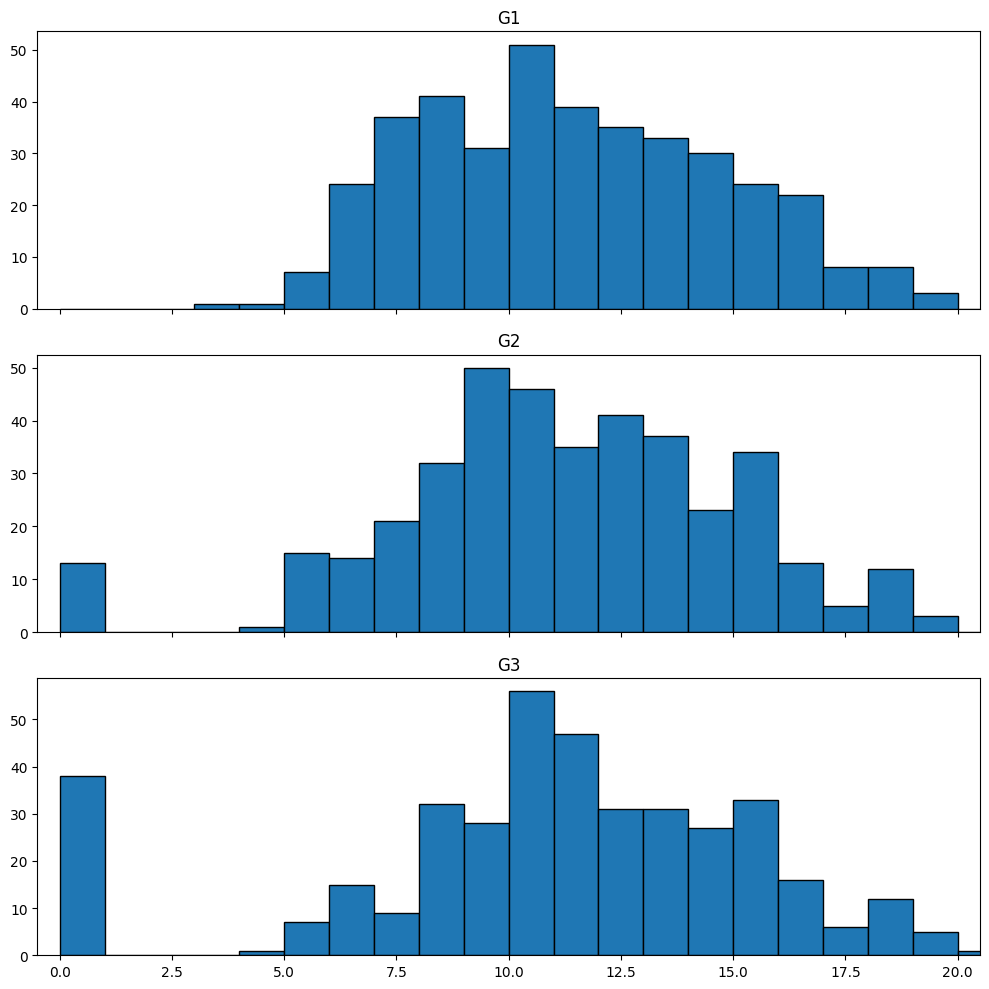

In [13]:
# ------------------------------------------------------------
# TARGET ENGINEERING (special case)
# Code for Step 3 and 4
# Target = count of failed subjects based on G1/G2/G3 < 10
# This is still REGRESSION (numeric target), but values are discrete.
# ------------------------------------------------------------

# --------------------------------------------
# Count number of subjects with score < 10
# from G1, G2, G3 (0 to 3)
# --------------------------------------------
grade_cols = ["G1", "G2", "G3"]

# True/False per subject, then sum across subjects (row-wise)
df["num_failed_subjects"] = (df[grade_cols] < 10).sum(axis=1)

# quick check
df[grade_cols + ["num_failed_subjects"]].head()
# --------------------------------------------
# Hist plots (3 by 1) for G1, G2, G3
# Use matplotlib only (no seaborn)
# --------------------------------------------
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axs[0].hist(df["G1"].dropna(), bins=range(0, 22), edgecolor="black")
axs[0].set_title("G1")

axs[1].hist(df["G2"].dropna(), bins=range(0, 22), edgecolor="black")
axs[1].set_title("G2")

axs[2].hist(df["G3"].dropna(), bins=range(0, 22), edgecolor="black")
axs[2].set_title("G3")

for ax in axs:
    ax.set_xlim(-0.5, 20.5)

plt.tight_layout()
plt.show()

# Quick sanity check you should do (in your own notes/report):
# - What are the unique values of the target?
# - What is the proportion of 0, 1, 2, 3?
# This helps you understand if the dataset is imbalanced by count.

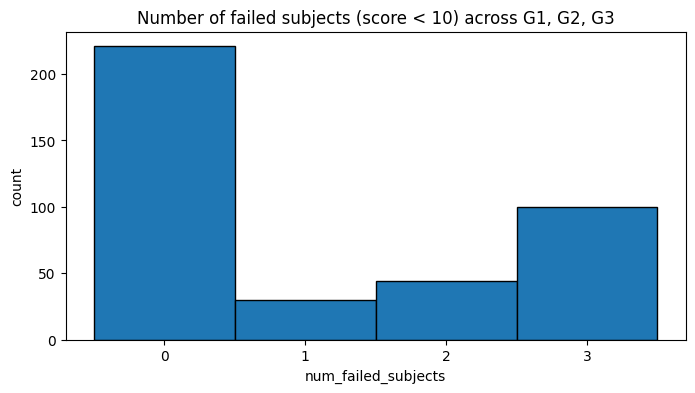

In [14]:
# ------------------------------------------------------------
# TARGET ENGINEERING (special case)
# Target = count of failed subjects based on G1/G2/G3 < 10
# This is still REGRESSION (numeric target), but values are discrete.
# ------------------------------------------------------------
# Optional: also plot the target distribution (0–3)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df["num_failed_subjects"].dropna(), bins=[-0.5, 0.5, 1.5, 2.5, 3.5], edgecolor="black")
plt.xticks([0, 1, 2, 3])
plt.title("Number of failed subjects (score < 10) across G1, G2, G3")
plt.xlabel("num_failed_subjects")
plt.ylabel("count")
plt.show()

# Quick sanity check you should do (in your own notes/report):
# - What are the unique values of the target?
# - What is the proportion of 0, 1, 2, 3?
# This helps you understand if the dataset is imbalanced by count.

###Useful code, for plotting predictors against categorical-type (including our count of subjects) prediction, to spot meaningful correlations and outliers.

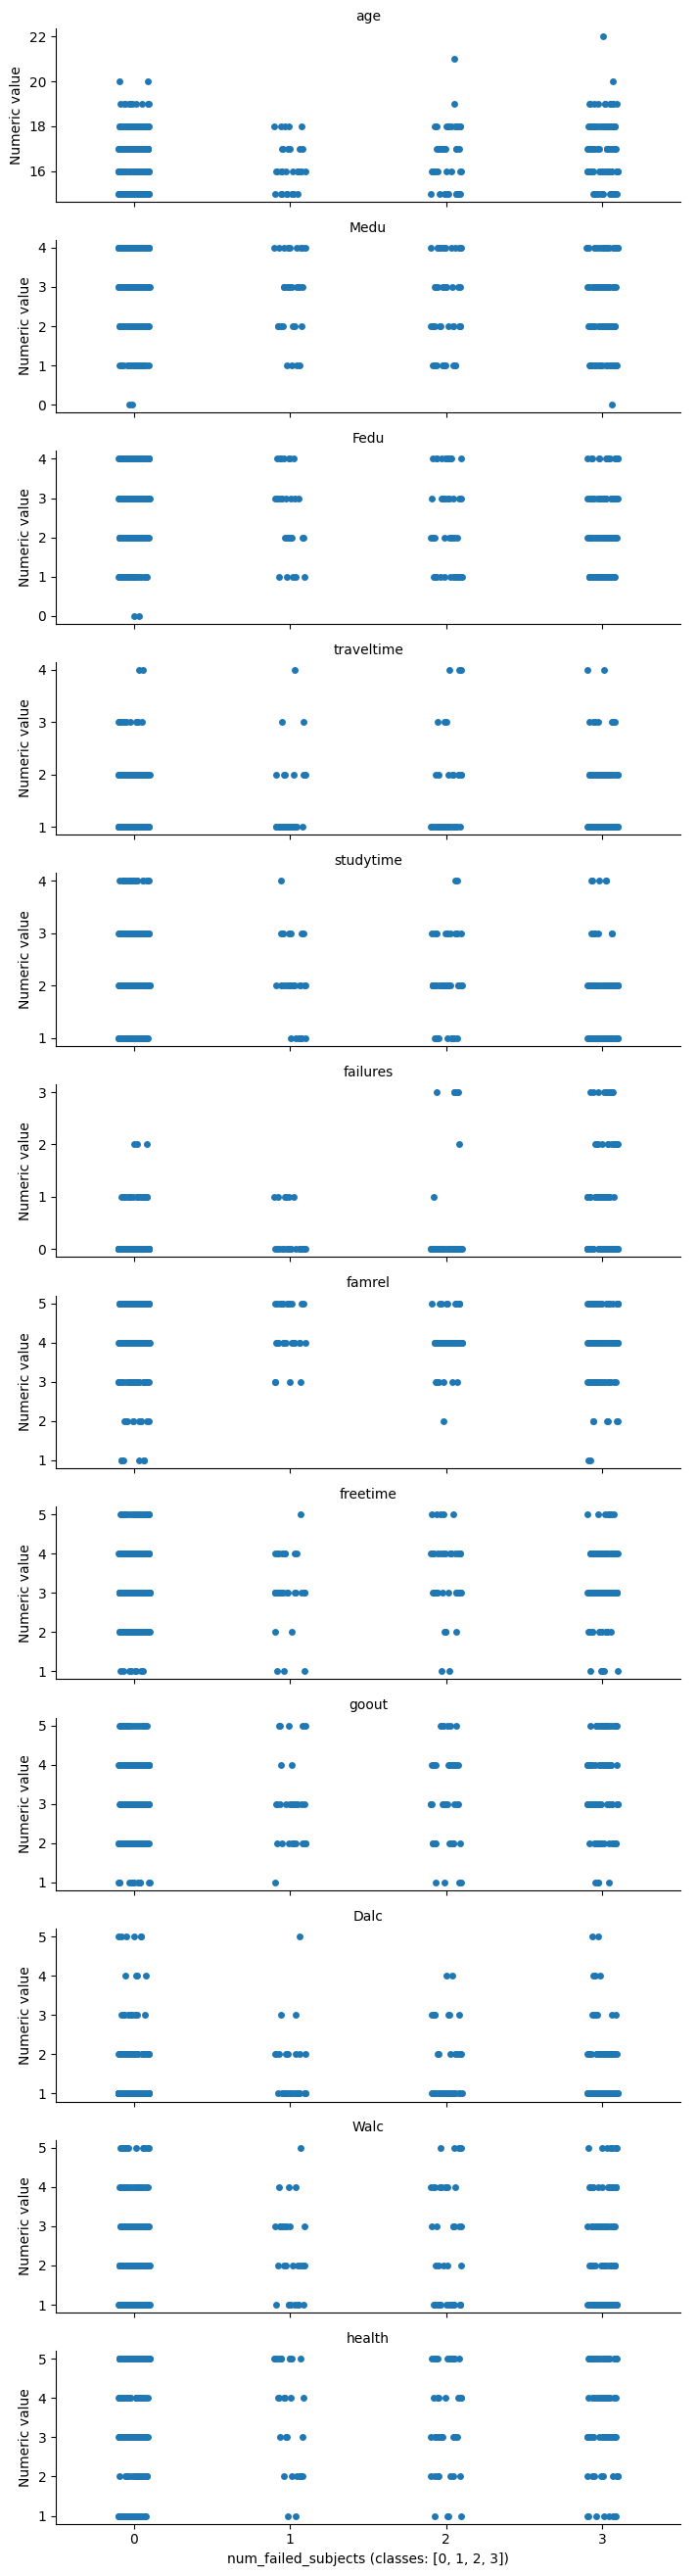

[0, 1, 2, 3] ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


In [15]:
# ============================================================
# Jitter plot: NUMERIC features vs DISCRETE target (fast)
# x = target classes, y = numeric values (one row facet per feature)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def jitter_numeric_fast(
    df: pd.DataFrame,
    target_col: str,
    num_cols: list[str] | None = None,
    order: list | None = None,
    max_features: int = 12,
    sample: int | None = 8000,
    max_classes: int = 12,
    class_order: str = "auto",  # "auto" | "sorted" | "freq"
    dropna_target: bool = True,
    dropna_feature: bool = True
):
    """
    Fast jitter plot for numeric features vs a discrete target.

    x = target classes
    y = numeric feature values (one facet per feature)

    Works for:
    - integer-coded targets (e.g. 0,1,2,3 or 1..5)
    - categorical/string targets (e.g. 'Low','Med','High')
    """

    if target_col not in df.columns:
        raise KeyError(f"target_col='{target_col}' not found in df")

    d = df.copy()

    # Drop missing target (usually safest)
    if dropna_target:
        d = d.dropna(subset=[target_col])

    # Auto-detect numeric columns (exclude target)
    if num_cols is None:
        num_cols = d.select_dtypes(include=[np.number]).columns.tolist()
        num_cols = [c for c in num_cols if c != target_col]

    # Keep only existing numeric columns
    num_cols = [c for c in num_cols if c in d.columns and c != target_col]
    if len(num_cols) == 0:
        raise ValueError("No numeric columns found to plot (after excluding target_col).")

    num_cols = num_cols[:max_features]

    # Decide x-axis order for target classes
    if order is None:
        y = d[target_col]

        # Ordered categorical: respect its category order (cap to max_classes)
        if isinstance(y.dtype, pd.CategoricalDtype) and y.dtype.ordered:
            order = list(y.cat.categories)
            if len(order) > max_classes:
                order = y.value_counts().head(max_classes).index.tolist()

        # Numeric target: prefer sorted unique (cap to max_classes)
        elif pd.api.types.is_numeric_dtype(y):
            uniq = pd.unique(y.dropna())
            order = sorted(uniq.tolist())
            if len(order) > max_classes:
                order = sorted(y.value_counts().head(max_classes).index.tolist())

        # String / object target: most frequent classes
        else:
            vc = y.astype("object").value_counts(dropna=False)
            order = vc.head(max_classes).index.tolist()
            if class_order == "sorted":
                order = sorted(order)
            elif class_order == "freq":
                order = order
            else:
                # auto: keep freq order
                order = order

    # Filter to chosen classes
    d = d[d[target_col].isin(order)].copy()

    # Sample once for speed
    if sample is not None and len(d) > sample:
        d = d.sample(sample, random_state=42)

    # Long form
    frames = []
    for c in num_cols:
        tmp = d[[target_col, c]].copy()
        if dropna_feature:
            tmp = tmp.dropna(subset=[c])
        tmp = tmp.rename(columns={c: "value"})
        tmp["feature"] = c
        frames.append(tmp[[target_col, "feature", "value"]])

    long_df = pd.concat(frames, ignore_index=True)

    # Force target order in seaborn
    long_df[target_col] = pd.Categorical(long_df[target_col], categories=order, ordered=True)

    g = sns.catplot(
        data=long_df,
        x=target_col,
        y="value",
        row="feature",
        kind="strip",
        order=order,
        jitter=True,
        height=2.2,
        aspect=3.2,
        sharey=False
    )

    g.set_axis_labels(f"{target_col} (classes: {order})", "Numeric value")
    g.set_titles("{row_name}")
    plt.tight_layout()
    plt.show()

    return order, num_cols


# Example:
order_used, num_cols_used = jitter_numeric_fast(df, target_col="num_failed_subjects", sample=15000)
print(order_used, num_cols_used)


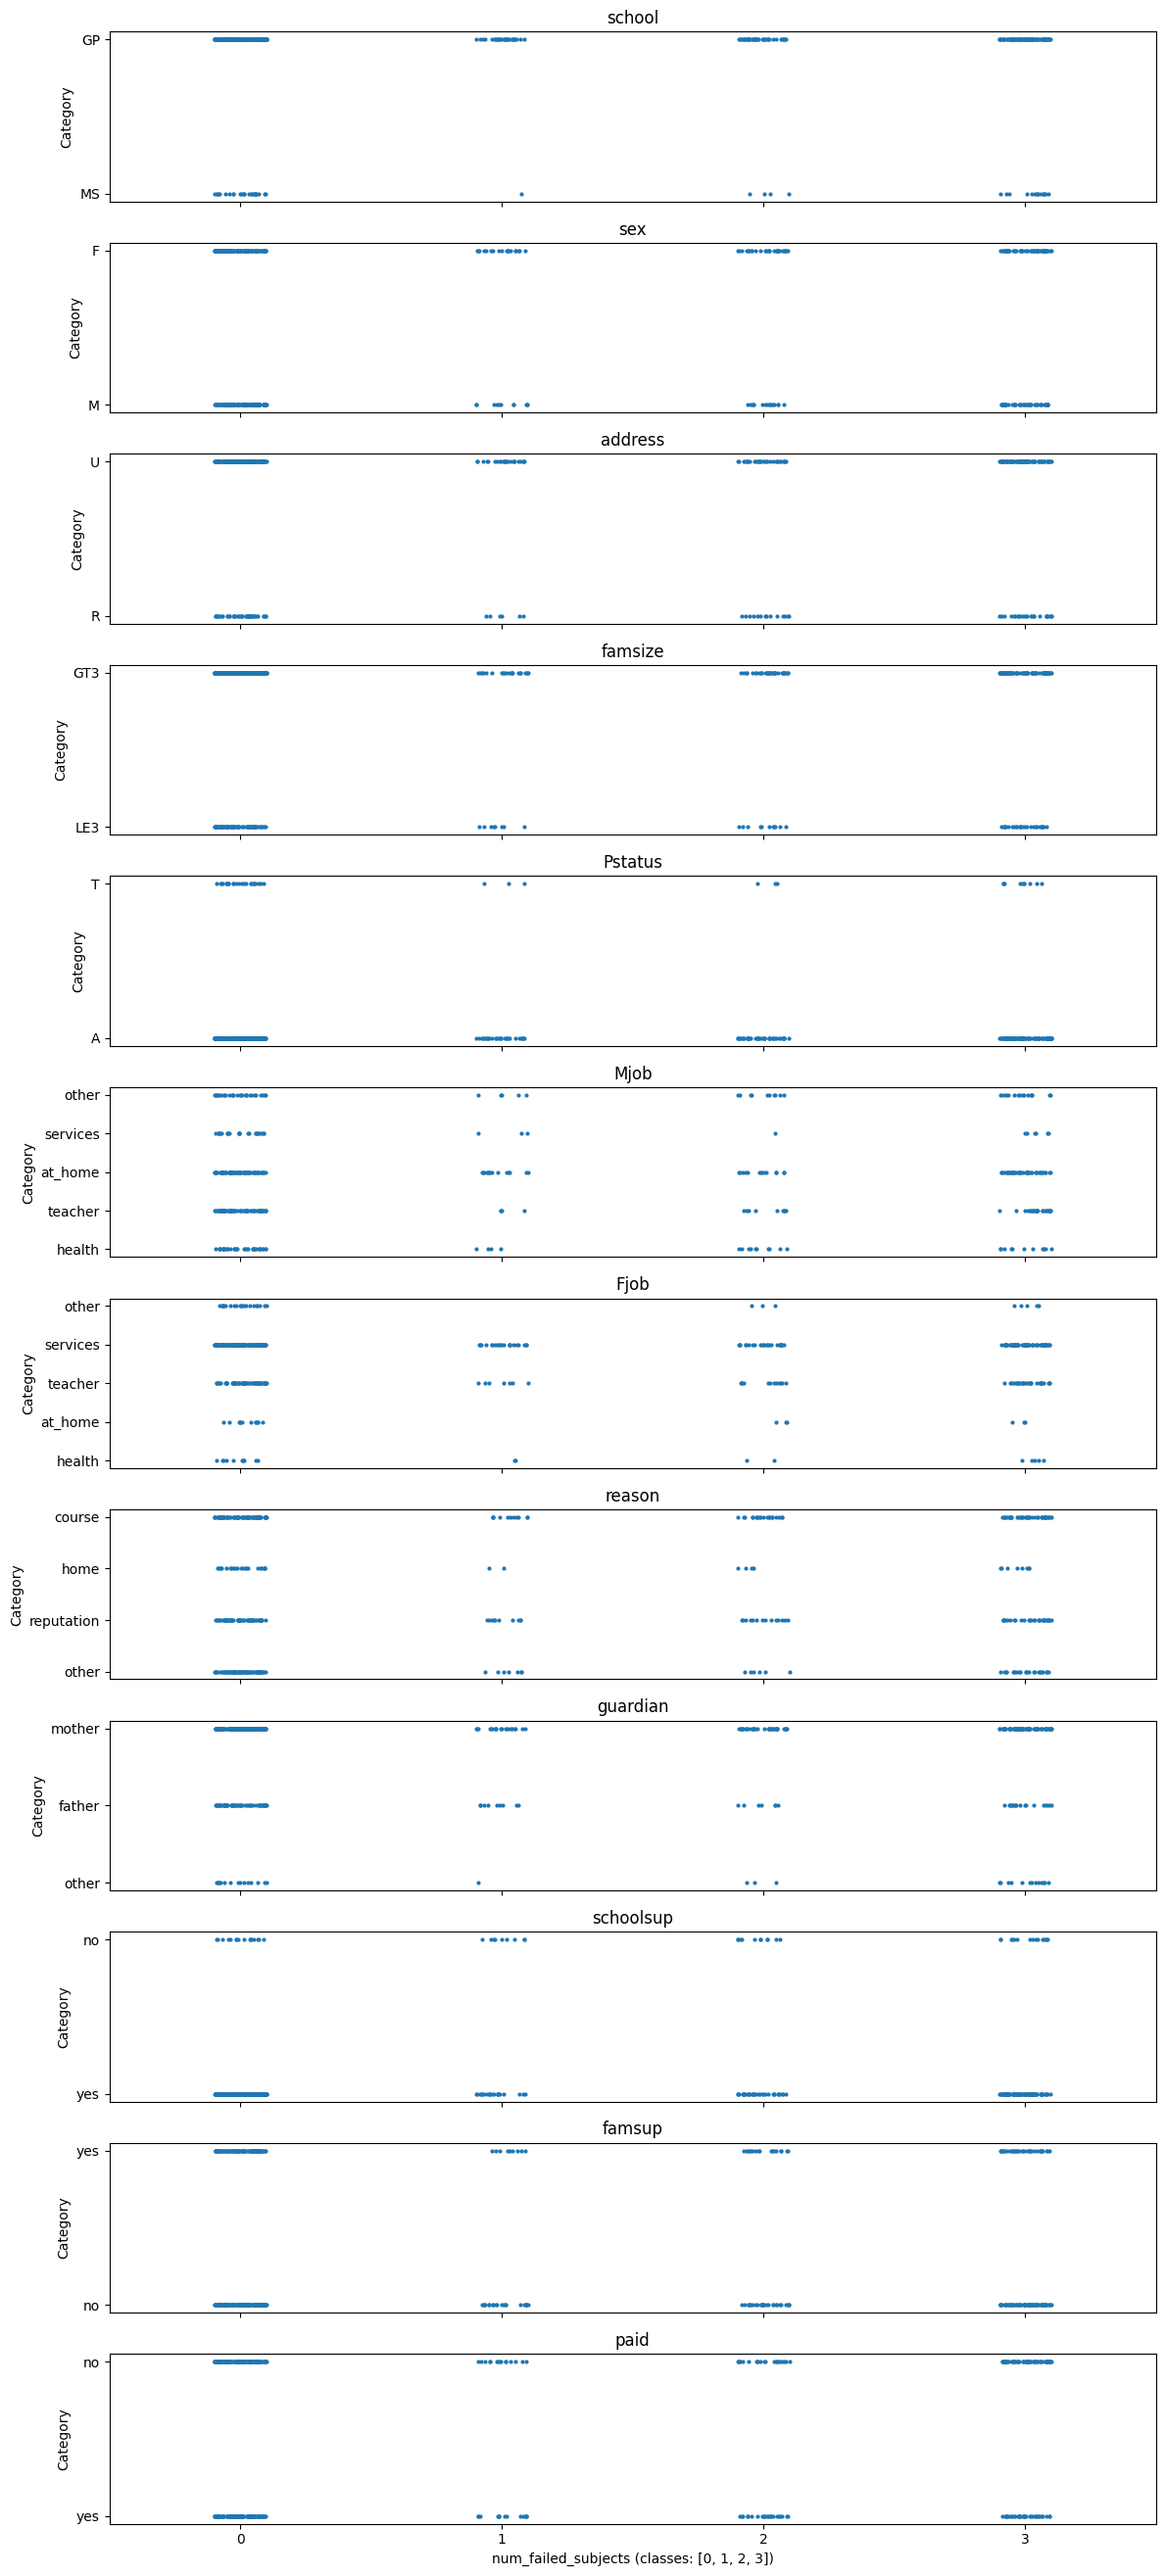

[0, 1, 2, 3] ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid']


In [16]:
# ============================================================
# Jitter plot: CATEGORICAL features vs DISCRETE target (fast)
# x = target classes, y = category levels (one row facet per feature)
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def jitter_categorical_fast(
    df: pd.DataFrame,
    target_col: str,
    cat_cols: list[str] | None = None,
    order: list | None = None,
    max_features: int = 12,
    sample: int | None = 8000,
    max_classes: int = 12,
    class_order: str = "auto",      # "auto" | "sorted" | "freq"
    dropna_target: bool = True,
    top_k: int = 15,                # keep top categories per feature, rest -> "Other"
    dropna_feature: bool = False,   # if False, show missing as "(Missing)"
    missing_label: str = "(Missing)",
    show_other: bool = True
):
    """
    Fast jitter plot for categorical features vs a discrete target.

    x = target classes
    y = categorical feature levels (one facet per feature)

    Notes:
    - For each categorical feature, rare categories are collapsed into "Other" (top_k kept).
    - Missing can be shown explicitly as missing_label.
    """

    if target_col not in df.columns:
        raise KeyError(f"target_col='{target_col}' not found in df")

    d = df.copy()

    # Drop missing target (usually safest)
    if dropna_target:
        d = d.dropna(subset=[target_col])

    # Decide x-axis order for target classes
    if order is None:
        y = d[target_col]

        if isinstance(y.dtype, pd.CategoricalDtype) and y.dtype.ordered:
            order = list(y.cat.categories)
            if len(order) > max_classes:
                order = y.value_counts().head(max_classes).index.tolist()

        elif pd.api.types.is_numeric_dtype(y):
            uniq = pd.unique(y.dropna())
            order = sorted(uniq.tolist())
            if len(order) > max_classes:
                order = sorted(y.value_counts().head(max_classes).index.tolist())

        else:
            vc = y.astype("object").value_counts(dropna=False)
            order = vc.head(max_classes).index.tolist()
            if class_order == "sorted":
                order = sorted(order)
            elif class_order == "freq":
                order = order
            else:
                order = order

    # Filter to chosen classes
    d = d[d[target_col].isin(order)].copy()

    # Sample once for speed
    if sample is not None and len(d) > sample:
        d = d.sample(sample, random_state=42)

    # Auto-detect categorical columns
    if cat_cols is None:
        cat_cols = d.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
        cat_cols = [c for c in cat_cols if c != target_col]

    cat_cols = [c for c in cat_cols if c in d.columns and c != target_col]
    if len(cat_cols) == 0:
        raise ValueError("No categorical columns found to plot (after excluding target_col).")

    cat_cols = cat_cols[:max_features]

    # Build long form with per-feature top_k collapsing
    frames = []
    for c in cat_cols:
        tmp = d[[target_col, c]].copy()

        if dropna_feature:
            tmp = tmp.dropna(subset=[c])
            tmp[c] = tmp[c].astype("object")
        else:
            tmp[c] = tmp[c].astype("object").fillna(missing_label)

        # Collapse rare categories to Other
        vc = tmp[c].value_counts(dropna=False)
        keep = vc.head(top_k).index.tolist()

        if show_other:
            tmp[c] = tmp[c].where(tmp[c].isin(keep), other="Other")
            # Make a stable y-order: keep list + "Other" (if present)
            y_order = [k for k in keep if k in tmp[c].unique()]
            if "Other" in tmp[c].unique() and "Other" not in y_order:
                y_order.append("Other")
        else:
            tmp = tmp[tmp[c].isin(keep)].copy()
            y_order = [k for k in keep if k in tmp[c].unique()]

        tmp = tmp.rename(columns={c: "value"})
        tmp["feature"] = c
        tmp["_y_order"] = [y_order] * len(tmp)
        frames.append(tmp[[target_col, "feature", "value", "_y_order"]])

    long_df = pd.concat(frames, ignore_index=True)

    # Force target order in seaborn
    long_df[target_col] = pd.Categorical(long_df[target_col], categories=order, ordered=True)

    # Faceted strip plot. We cannot pass a different y-order per facet directly,
    # so we do a small loop to respect each feature's y-order.
    features = long_df["feature"].unique().tolist()
    n = len(features)

    fig, axes = plt.subplots(n, 1, figsize=(12, max(2.2 * n, 2.2)), sharex=True)
    if n == 1:
        axes = [axes]

    for ax, feat in zip(axes, features):
        sub = long_df[long_df["feature"] == feat].copy()
        y_order = sub["_y_order"].iloc[0]

        sns.stripplot(
            data=sub,
            x=target_col,
            y="value",
            order=order,
            jitter=True,
            size=3,
            ax=ax
        )

        ax.set_title(feat)
        ax.set_ylabel("Category")
        ax.set_xlabel("")
        ax.set_yticks(range(len(y_order)))
        ax.set_yticklabels(y_order)

    axes[-1].set_xlabel(f"{target_col} (classes: {order})")
    plt.tight_layout()
    plt.show()

    return order, cat_cols


# Example:
order_used, cat_cols_used = jitter_categorical_fast(df, target_col="num_failed_subjects", sample=15000, top_k=12)
print(order_used, cat_cols_used)



##Step 10-2 Create the target: number of failed subjects (special target)

Here you convert **three subject grades** into **one target**:

- A subject is considered **failed** when grade `< 10`.
- You count how many of the three subjects are failed.

### Common mistakes to avoid
- Using `<= 10` by accident (that changes the definition).
- Counting missing values as fails (check for missing grades first).
- Forgetting to confirm the **range** of the new target (it should usually be 0–3).


### What to look for in quick checks

Standard checks you should be able to explain:
- `df.shape`: how many rows and columns (scale)
- `df.info()`: data types and missing values (readiness)
- `df.describe(include="all")`: typical values, outliers, rare categories (risk)

Common edge cases:
- `0` might mean a real value, or it might mean *missing coded as 0* (depends on the dataset).
- Some columns look numeric but are actually IDs or codes. Treat those carefully.


# **Step : 11 Create X set & y set before split into Train & Test set**
# **Have 2 prompts : Target column known & create new target column and drop some columns** before split X & y set.

In [17]:
# Prompt 1 : New Target Creation

# ============================================================
# Universal: Target Creation + Dataset Overview Before Modelling
# Works whether cleaning was performed or not
# ============================================================

# Use cleaned data if available, otherwise use original df
data = df_clean if "df_clean" in globals() else df

# ------------------------------------------------------------
# Create Target Column (Mock Practical Test Example)
# Count number of failed subjects (<10)
# ------------------------------------------------------------

target_col = "num_failed_subjects"

if target_col not in data.columns:

    grade_cols = ["G1", "G2", "G3"]

    data[target_col] = (
        (data[grade_cols] < 10)
        .sum(axis=1)
    )

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X = data.drop(
    columns=[target_col, "G1", "G2", "G3"],
    errors="ignore"
)

y = data[target_col]

# ------------------------------------------------------------
# Dataset Overview Before Modelling
# ------------------------------------------------------------

print("Target:", target_col)

print("\nTarget Distribution:")
display(
    y.value_counts(normalize=True)
     .sort_index()
     .to_frame("Proportion")
)

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

print("\nNumber of Predictors:", X.shape[1])

print("\nPredictor Columns:")
display(pd.DataFrame(X.columns, columns=["Predictor"]))

print("\nFirst 5 Rows of X:")
display(X.head())

Target: num_failed_subjects

Target Distribution:


,Proportion
num_failed_subjects,
0,0.559494
1,0.075949
2,0.111392
3,0.253165



X Shape: (395, 64)
y Shape: (395,)

Number of Predictors: 64

Predictor Columns:


,Predictor
0,school
1,sex
2,age
3,address
4,famsize
...,...
59,invalid_health_range
60,invalid_G1_range
61,invalid_G2_range
62,invalid_G3_range



First 5 Rows of X:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,emptystr_school,emptystr_sex,emptystr_address,emptystr_famsize,emptystr_Pstatus,emptystr_Mjob,emptystr_Fjob,emptystr_reason,emptystr_guardian,emptystr_schoolsup,emptystr_famsup,emptystr_paid,emptystr_activities,emptystr_nursery,emptystr_higher,emptystr_internet,emptystr_romantic,absences_outlier_iqr,invalid_age_range,invalid_Medu_range,invalid_Fedu_range,invalid_traveltime_range,invalid_studytime_range,invalid_failures_range,invalid_famrel_range,invalid_freetime_range,invalid_goout_range,invalid_Dalc_range,invalid_Walc_range,invalid_health_range,invalid_G1_range,invalid_G2_range,invalid_G3_range,invalid_absences_range
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Prompt 2 : Target Column already exist

# ============================================================
# Existing Target + Dataset Overview Before Modelling
# Works whether cleaning was performed or not
# ============================================================

# Use cleaned data if available, otherwise use original df
data = df_clean if "df_clean" in globals() else df

# ------------------------------------------------------------
# Specify Existing Target Column
# ------------------------------------------------------------

target_col = "Price"   # <-- Change to actual target

# ------------------------------------------------------------
# Create X and y
# ------------------------------------------------------------

X = data.drop(
    columns=[target_col],
    errors="ignore"
)

y = data[target_col]

# ------------------------------------------------------------
# Dataset Overview Before Modelling
# ------------------------------------------------------------

print("Target:", target_col)

print("\nTarget Distribution:")

if y.nunique() <= 20:
    display(
        y.value_counts(normalize=True)
         .sort_index()
         .to_frame("Proportion")
    )
else:
    print("Target has many unique values.")
    print(y.describe())

print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

print("\nNumber of Predictors:", X.shape[1])

print("\nPredictor Columns:")
display(pd.DataFrame(X.columns, columns=["Predictor"]))

print("\nFirst 5 Rows of X:")
display(X.head())

In [ ]:
# for reference only (If no data cleaning )
# Class balance (important for evaluation choices)
target_col = "num_failed_subjects"
df[target_col].value_counts(normalize=True)

,proportion
num_failed_subjects,
0,0.559494
3,0.253165
2,0.111392
1,0.075949


In [ ]:
# for reference only (If no data cleaning )
# dropped the columns (use df_clean.drop in both X & y  => If data set already clean)

X = df.drop(columns=[target_col, "G2", "G3", "G1"])
y = df[target_col]
X.shape, y.shape

((395, 30), (395,))

In [ ]:
# for reference only (If no data cleaning )
# show all remaining predictor columns
X.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences']

In [ ]:
# for reference only (If no data cleaning )
# Show all remaining columns used for modelling (Same as X.columns.tolist())

print("Columns used for modelling:")

for col in X.columns:
    print(col)

Columns used for modelling:
school
sex
age
address
famsize
Pstatus
Medu
Fedu
Mjob
Fjob
reason
guardian
traveltime
studytime
failures
schoolsup
famsup
paid
activities
nursery
higher
internet
romantic
famrel
freetime
goout
Dalc
Walc
health
absences


In [ ]:
# for reference only (If no data cleaning )
# Check shape after dropping
print(X.shape)

(395, 30)


In [ ]:
# for reference only (If no data cleaning )
# Dataset overview before modelling

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget:")
print(target_col)

print("\nColumns in X:")
display(pd.DataFrame(X.columns, columns=["Predictor"]))


X Shape: (395, 30)
y Shape: (395,)

Target:
num_failed_subjects

Columns in X:


,Predictor
0,school
1,sex
2,age
3,address
4,famsize
5,Pstatus
6,Medu
7,Fedu
8,Mjob
9,Fjob


# **Step 12) Split into train and test sets**

**Goal:** ensure you evaluate on unseen data.

Revision reminders:
- Use the same `random_state` for reproducibility.
- For regression, you usually do **not** stratify (unless you bucket the target).
- Keep the test set untouched until final evaluation.


# **Template A: Regression / Continuous Numeric Target**
Use when the target is: Price, Salary, Sales, Revenue, HousePrice etc.

In [18]:
# Template A: Regression/Continuous Numeric target
# Split into Train and test sets

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# Regression
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (355, 64)
X_test : (40, 64)
y_train: (355,)
y_test : (40,)


# **Template B: Classification Target**
Use when target is: Churn, Fraud, Attrition, Loan_status, Yes/No, Low/Medium/High etc.

In [24]:
# Template B: Classification Target
# Split Train / Test sets

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# Classification
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train distribution:")
print(y_train.value_counts(normalize=True))

print("\ny_test distribution:")
print(y_test.value_counts(normalize=True))

X_train: (355, 64)
X_test : (40, 64)
y_train distribution:
num_failed_subjects
0    0.560563
3    0.253521
2    0.109859
1    0.076056
Name: proportion, dtype: float64

y_test distribution:
num_failed_subjects
0    0.550
3    0.250
2    0.125
1    0.075
Name: proportion, dtype: float64


### Train/test split: what you are protecting against

**Standard definition:**  
A train/test split separates data you learn from (train) and data you hold back for final checking (test). This helps you estimate how well the model will work on new cases.

**Why `stratify=y` matters:**  
If classes are imbalanced, stratification keeps the class ratios similar in train and test.

**Edge case:**  
If a class is extremely rare, stratified splitting can fail or create tiny class counts. In that case, you may need a different split strategy or simpler target grouping.


# **Step 13: Identify Numeric and Categorical Columns**


Numeric Columns
→ StandardScaler
→ Median Imputation

Categorical Columns
→ OneHotEncoder
→ Most Frequent Imputation


In [19]:
# ------------------------------------------------------------
# Identify Numeric and Categorical Columns
# ------------------------------------------------------------

cat_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

num_columns = X_train.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("Categorical Columns:")
print(cat_columns)

print("\nNumeric Columns:")
print(num_columns)

Categorical Columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numeric Columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'emptystr_school', 'emptystr_sex', 'emptystr_address', 'emptystr_famsize', 'emptystr_Pstatus', 'emptystr_Mjob', 'emptystr_Fjob', 'emptystr_reason', 'emptystr_guardian', 'emptystr_schoolsup', 'emptystr_famsup', 'emptystr_paid', 'emptystr_activities', 'emptystr_nursery', 'emptystr_higher', 'emptystr_internet', 'emptystr_romantic', 'absences_outlier_iqr', 'invalid_age_range', 'invalid_Medu_range', 'invalid_Fedu_range', 'invalid_traveltime_range', 'invalid_studytime_range', 'invalid_failures_range', 'invalid_famrel_range', 'invalid_freetime_range', 'invalid_goout_range', 'invalid_Dalc_range', 'invalid_Walc_range', 'invalid_health_range', 'invalid


# **Step 14 Preprocessing (critical for mixed columns)**

Most real datasets contain both:
- numeric columns (need scaling sometimes, missing values handling)
- categorical columns (need encoding, missing values handling)

**Tip:** In a practical test, a clean `ColumnTransformer` + `Pipeline` is often the best answer because:
- it reduces leakage,
- it ensures the same steps apply to train and test,
- it makes your workflow reproducible.


# **PREPROCESSOR (for feature columns (x)**

**Numeric Features** -> StandardScaler (Linear Regression, Logistic Regression, KNN, SVM)

**Categorical Features** -> OneHotEncoder (DecisionTreeRegressor, DecisiontreeClassifer, Random Forest, RandomForestRegressor, RandomForestclassifier, SGBoost, XGBRegressor, XGBClassifier, Gradient Boosting, GradientBoostingRegressor, GradientBoostingClassifier bold text


**No Standardscaler Needed**: DecisionTreeRegressor & DecisionTreeClassifier / RandomForestRegressor
& RandomForestClassifier / XGBRegressor
& XGBClassifier

**Standardscaler recommended**: LinearRegression & LogisticRegression / KNeighborsRegressor & KNeighborsClassifier / SVR / SVC

In [21]:
# Preprocessor if also need standardscaler for numeric columns  ** use this one **
# for situations where the model benefits from scaling (Model: Linear Regression, Logistic Regression, KNeighborsRegressor, KneighborsClassifier, SVR, SVC, Neural Network etc.).
# Standardscaler + OneHotEncoder
# ------------------------------------------------------------
# PREPROCESSOR for Linear Regression, Logistic Regression, KNN, SVM
# Numeric: StandardScaler
# Categorical: OneHotEncoder
# ------------------------------------------------------------

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Identify Numeric and Categorical Features
# ------------------------------------------------------------
num_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

# ------------------------------------------------------------
# Build Preprocessor
# ------------------------------------------------------------


cat_features = X_train.select_dtypes(
    exclude=[np.number]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ],
    remainder="drop"
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'Medu', 'Fedu', 'traveltime',
                                  'studytime', 'failures', 'famrel', 'freetime',
                                  'goout', 'Dalc', 'Walc', 'health', 'absences',
                                  'emptystr_school', 'emptystr_sex',
                                  'emptystr_address', 'emptystr_famsize',
                                  'emptystr_Pstatus', 'emptystr_Mjob',
                                  'emptystr_Fjob', 'emptystr_reason',
                                  'emptystr_guardian', 'emptystr_schoo...
                                  'emptystr_famsup', 'emptystr_paid',
                                  'emptystr_activities', 'emptystr_nursery',
                                  'emptystr_higher', 'emptystr_internet',
                                  'emptystr_romantic', ...]),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['school', 'sex', 'address', 'famsize',
                                  'Pstatus', 'Mjob', 'Fjob', 'reason',
                                  'guardian', 'schoolsup', 'famsup', 'paid',
                                  'activities', 'nursery', 'higher', 'internet',
                                  'romantic'])])

In [30]:
# Preprocessor for Model: DecisionTreeRegressor, DecisionTreeClassifier, RandomForestRegressor, RandomForestClassifier,XGBRegressor, XGBClassifier, Gradient Boosting, LightGBM
# ------------------------------------------------------------
# PREPROCESSOR for Decision Tree, Random Forest, XGBoost
# Make sure preprocessing is inside a Pipeline to avoid leakage.
# Only Categorial:  OnehotCoder
# ------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Identify columns by dtype
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ],
    remainder="drop"
)

num_features[:10], cat_features[:10]


(['age',
  'Medu',
  'Fedu',
  'traveltime',
  'studytime',
  'failures',
  'famrel',
  'freetime',
  'goout',
  'Dalc'],
 ['school',
  'sex',
  'address',
  'famsize',
  'Pstatus',
  'Mjob',
  'Fjob',
  'reason',
  'guardian',
  'schoolsup'])

In [29]:
# Another template

# ============================================================
# PREPROCESSOR
# Numeric Features -> StandardScaler
# Categorical Features -> OneHotEncoder
# ============================================================

import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ------------------------------------------------------------
# Identify Numeric and Categorical Features
# ------------------------------------------------------------

num_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

cat_features = X_train.select_dtypes(
    exclude=[np.number]
).columns.tolist()

# ------------------------------------------------------------
# Build Preprocessor
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            cat_features
        )
    ],
    remainder="drop"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("Number of Numeric Features:", len(num_features))
print("Number of Categorical Features:", len(cat_features))

print("\nNumeric Features:")
print(num_features)

print("\nCategorical Features:")
print(cat_features)

print("\nPreprocessor Created Successfully:")
print(preprocessor)

Number of Numeric Features: 47
Number of Categorical Features: 17

Numeric Features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'emptystr_school', 'emptystr_sex', 'emptystr_address', 'emptystr_famsize', 'emptystr_Pstatus', 'emptystr_Mjob', 'emptystr_Fjob', 'emptystr_reason', 'emptystr_guardian', 'emptystr_schoolsup', 'emptystr_famsup', 'emptystr_paid', 'emptystr_activities', 'emptystr_nursery', 'emptystr_higher', 'emptystr_internet', 'emptystr_romantic', 'absences_outlier_iqr', 'invalid_age_range', 'invalid_Medu_range', 'invalid_Fedu_range', 'invalid_traveltime_range', 'invalid_studytime_range', 'invalid_failures_range', 'invalid_famrel_range', 'invalid_freetime_range', 'invalid_goout_range', 'invalid_Dalc_range', 'invalid_Walc_range', 'invalid_health_range', 'invalid_G1_range', 'invalid_G2_range', 'invalid_G3_range', 'invalid_absences_range']

Categorical Features:
['school', 'sex', 'address', 'fa

# **For Practical test **

Preprocessor:
Explanation:

The preprocessor prepares the data for modelling. Numeric columns are kept as-is, while categorical columns are converted into numerical format using OneHotEncoder so that the machine learning model can process them.

Modelling: DecisionTreeRegressor()
Explanation:

The model learns patterns between predictor variables and the target variable. It uses these patterns to estimate the target value for unseen records.

** Predict** number of failed subjects
 so:

The model learns relationships between student characteristics and the expected number of failed subjects.

**Why use a Pipeline?**
Explanation:

A pipeline combines preprocessing and modelling into a single workflow. This helps ensure that the same preprocessing steps are applied consistently to both training and testing data, reducing the risk of data leakage and mistakes.

# **Step 15: Simple Baseline Regression Model (Train a simple baseline model)**

Ensure: already completed X_train, y_train & Preprocessor

# **Step 15-1: Template Train a Baseline model (Regression Model)**

Pipeline : all things in pipeline will go inside the baseline model (DecisionTreeRegressor) No data mistake could happen when use pipeline. All steps are done accordingly and consistency. Increaese accuracy.

**Base line: Decision Tree is the simplest (DecisionTreeRegressor)** follow by linear regression (Data is all numeric)

Random Forest will be more complex.

In [22]:
# Template A: Train a simple Baseline regression Model

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


##  Evaluate the baseline model

**Suggested time:** 12 minutes

We use three common regression metrics.

| Metric | Plain meaning | Better when |
|---|---|---|
| MAE | Average absolute error in dollars | Lower is better |
| RMSE | Error that punishes large mistakes more | Lower is better |
| R² | How much variation is explained | Higher is better |

For business explanation, MAE is often easiest because it is in the same unit as the target: Singapore dollars.

R2 => Expected to close to 1


In [23]:
# Baseline model Evaluation (Can be used with mose regression datasets)
# If evaluate other regression model. replace basedline_model with model name
# eg. y_pred =rf_model.predict(X_test)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

y_pred = baseline_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.0894642437073627
RMSE: 1.3772713986438285
R²  : -0.0049676850449418275


Translation: The baseline Decision Tree Regressor achieved an MAE of 1.09 and RMSE of 1.38. This indicates that predictions are off by approximately one failed subject on average. The R² value of -0.005 suggests that the baseline model has limited predictive power and performs slightly worse than predicting the mean target value. Therefore, more advanced models such as Random Forest or XGBoost should be explored to improve performance.

Next model should ideally achieve: 1. Lower MAE
2 Lower RMSE  3 Higher R²

# **Step 15-2: Template B Actual model**
# ** Tuned Model (Random Forest)  ** Modeling

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'Medu', 'Fedu',
                                                   'traveltime', 'studytime',
                                                   'failures', 'famrel',
                                                   'freetime', 'goout', 'Dalc',
                                                   'Walc', 'health', 'absences',
                                                   'emptystr_school',
                                                   'emptystr_sex',
                                                   'emptystr_address',
                                                   'emptystr_famsize',
                                                   'emptystr_Pstatus',
                                                   'emptystr_Mjob',
                                                   'emptystr_Fjob',
                                                   'emptystr_reason',
                                                   'em...
                                                   'emptystr_activities',
                                                   'emptystr_nursery',
                                                   'emptystr_higher',
                                                   'emptystr_internet',
                                                   'emptystr_romantic', ...]),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['school', 'sex', 'address',
                                                   'famsize', 'Pstatus', 'Mjob',
                                                   'Fjob', 'reason', 'guardian',
                                                   'schoolsup', 'famsup',
                                                   'paid', 'activities',
                                                   'nursery', 'higher',
                                                   'internet', 'romantic'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [25]:
# Evaluation code for Random Forest model (rf_model)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

# Predictions
y_pred = rf_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Results
---------------------
MAE : 1.0425
RMSE: 1.2096962428642986
R²  : 0.224707284768212


The Random Forest model reduced the average prediction error compared to the baseline Decision Tree model.

Decision Tree (Baseline) MAE  = 1.0895
RMSE = 1.3773
R²   = -0.0050

Random Forest MAE  = 1.0433
RMSE = 1.2108
R²   = 0.2233

Interpretation:
MAE Improved: 1.0895 → 1.0433 (The Random Forest model reduced the average prediction error compared to the baseline Decision Tree model.)
RMSE Improved: 1.3773 → 1.2108 (The Random Forest model produced lower RMSE, suggesting fewer large prediction errors than the baseline model.)
R² Improved Significantly : -0.0050 → 0.2233 (This is the biggist improvement. Baseline not explaining the target variation but RF explains approximately 22.3%) Random Forest achieved an R² of 0.223, indicating a substantial improvement over the baseline Decision Tree model.

**A good write-up would be:**

The Random Forest model outperformed the baseline Decision Tree model across all evaluation metrics. MAE decreased from 1.089 to 1.043, RMSE decreased from 1.377 to 1.211, and R² increased from -0.005 to 0.223. This indicates that Random Forest captures the underlying patterns in the data more effectively and provides more accurate predictions.

# **Step 15: Template C Tuned Model (XGBoost)**

In [26]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(random_state=42))
    ]
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained.")

XGBoost model trained.


In [27]:
# Evaluation template for XGBoost model (It's can be use for all Regression: DecisionTreeRegressor, RandomForestRegressor, SBGRegressor, LinearRegression, SVR, KneighborsRegressor)

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost Results")
print("----------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

XGBoost Results
----------------
MAE : 0.9357330203056335
RMSE: 1.1773834228515625
R²  : 0.26557254791259766



##Step 8) Build a model pipeline

**Revision goal:** You should be able to explain:
- What the preprocessor does
- What the model does
- Why a pipeline prevents mistakes

### Special note for this target
Even though the true target is a small set of integers (Round number), your regression model might output non-integers.
That is normal.

If the task requires integer predictions, you can *post-process* predictions (rounding),
but only do this if instructed, and always state the trade-off (it can change metrics).

### Evaluate using regression metrics

In a practical test, explain metrics in simple terms:

- **MAE**: average absolute error (easy to explain in grade points)
- **RMSE**: penalises large errors more strongly
- **R²**: how much variance is explained (can be misleading if target range is small)

### Edge case reminder
Because your target range is small (often 0–3), R² may look low even if errors are small.
So you should always report MAE or RMSE too.


For practical test: Although the target variable contains integer values (0 to 3 failed subjects), a regression model may produce decimal predictions such as 1.8 or 2.3. This is expected because regression models estimate continuous numeric values.

# **Step 15: Template D: Cross Validation:

Hyperparameter Tuning with GridSearchCV  (From Mock practical test)**  => Train many randomForest

In [28]:
# ------------------------------------`
# 0. NOTE: This block takes quite a while to run, do it before moving onto explanation of code
# ------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import ShuffleSplit
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
# -------------------------------------------
# 1. Create pipelines for both models
# -------------------------------------------

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        random_state=42))
])

# -------------------------------------------
# 2. Define parameter grids
# Keep them small for speed and simplicity
# -------------------------------------------

param_grid_rf = {
  "regressor__n_estimators": [50, 200],
  'regressor__max_depth':[5,10, None],
  'regressor__criterion':['squared_error', 'absolute_error']
}

param_grid_xgb = {
    "regressor__n_estimators": [50, 200],
  'regressor__max_depth':[2,4,6],
  'regressor__eval_metric':['rmse', 'mae']
}

# -------------------------------------------
# 3. Create GridSearchCV objects
# -------------------------------------------

gs_rf = GridSearchCV(
    estimator=pipe_rf,
    param_grid=param_grid_rf,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

gs_xgb = GridSearchCV(
    estimator=pipe_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

# -------------------------------------------
# 4. Fit both models
# (Students can run one at a time if needed)
# -------------------------------------------e

gs_rf.fit(X_train, y_train)
print("Random Forest grid search complete.")

gs_xgb.fit(X_train, y_train)
print("XGBoost grid search complete.")


Fitting 10 folds for each of 12 candidates, totalling 120 fits
Random Forest grid search complete.
Fitting 10 folds for each of 12 candidates, totalling 120 fits
XGBoost grid search complete.


**creating a score tracking table "Lab book"**

Store model performance
↓
Compare different models
↓
Choose the best model

Without table, Hard to compare

In [30]:
#setup a results df to hold training and test scores
#at this point, you should already decide what scoring metric you going to use
#regression: r2, mae, rmse, mape

#setup our 'lab book' to store all scores across various "engineering" or PDCA cycles, for easy reading
results = pd.DataFrame(['cv_mae_val', 'cv_std_val', 'cv_mae_train', 'cv_std_train','holdout_mae','best para'])

In [31]:
import numpy as np
from sklearn.model_selection import ShuffleSplit, cross_validate

cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

# -----------------------------------------
# 1) CV diagnostics on TRAIN only
#    cross_validate gives train_score and test_score
# -----------------------------------------
best_model = gs_xgb.best_estimator_

cv_out = cross_validate(
    best_model,
    X_train, y_train,
    cv=cv,
    scoring="neg_mean_absolute_error",
    return_train_score=True,
    n_jobs=-1,
    error_score="raise"
)

# Convert negative MAE to positive MAE
val_mae_scores = -cv_out["test_score"]
train_mae_scores = -cv_out["train_score"]

cv_mae_val_mean = float(val_mae_scores.mean())
cv_mae_val_std  = float(val_mae_scores.std())

cv_mae_train_mean = float(train_mae_scores.mean())
cv_mae_train_std  = float(train_mae_scores.std())

# -----------------------------------------
# 2) Holdout MAE (fit once, evaluate once)
# -----------------------------------------
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
holdout_mae = float(np.mean(np.abs(y_test - y_pred)))

# -----------------------------------------
# 3) Save into results (same 6-row lab book)
# -----------------------------------------
results["XGB_llm_encode_tuned"] = [
    cv_mae_val_mean,
    cv_mae_val_std,
    cv_mae_train_mean,
    cv_mae_train_std,
    holdout_mae,
    gs_xgb.best_params_,
]

display(results)


,0,XGB_llm_encode_tuned
0,cv_mae_val,1.04717
1,cv_std_val,0.068595
2,cv_mae_train,0.655714
3,cv_std_train,0.018854
4,holdout_mae,0.994955
5,best para,"{'regressor__eval_metric': 'rmse', 'regressor_..."


### Grid search and CV: what to do if time is tight

**Standard definition:**  
Cross-validation (CV) repeats training on different splits to reduce “lucky/unlucky split” effects. Grid search tries multiple hyperparameter settings.

**Practical-test approach (recommended):**
1. Build a baseline model and report results.
2. Improve **one thing only** (for example: class weighting, simpler preprocessing, or a small grid).

If you run the full grid search, note the runtime and what you would do to speed it up.



##Step 9) Error analysis (what to look for)

When you plot predictions or residuals, check:

- Do you systematically over-predict or under-predict?
- Are errors bigger for certain ranges (e.g., predicting 2 or 3 fails)?
- Do you see outliers that might come from data issues?

This is where you decide what to improve next.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# USER SETTINGS (edit these only)
# -----------------------------------------
sort_col = "Mjob"   # any column in X_test (e.g. "Brand", "GPU", "Screen_Size_inch")
step_n  = 1         # sample every n-th row after sorting

# -----------------------------------------
# 1. Sort by chosen column
# -----------------------------------------
sorted_idx = X_test[sort_col].sort_values().index

X_sorted = X_test.loc[sorted_idx]
y_sorted = y_test.loc[sorted_idx]

# 🔄 XGBoost prediction instead of RF
y_pred_sorted = gs_xgb.best_estimator_.predict(X_sorted)

# Combine into one DataFrame
df_plot = X_sorted.copy()
df_plot["Actual"] = y_sorted.values
df_plot["Predicted"] = y_pred_sorted

# -----------------------------------------
# 2. Apply sampling with iloc[::step_n]
# -----------------------------------------
df_plot = df_plot.iloc[::step_n].reset_index(drop=True)

group_series = df_plot[sort_col]
unique_groups = group_series.unique()

# colour palette based on unique groups
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_groups)))

# Find spans for shading
spans = []
start = 0
for i in range(1, len(group_series)):
    if group_series[i] != group_series[i - 1]:
        spans.append((start, i - 1, group_series[i - 1]))
        start = i
spans.append((start, len(group_series) - 1, group_series.iloc[-1]))

# -----------------------------------------
# 3. Plot with shading + sampled lines
# -----------------------------------------
fig, ax = plt.subplots(figsize=(24, 6))

# Background shading (color spelling is correct)
for idx, (s, e, group_name) in enumerate(spans):
    ax.axvspan(s, e, color=colors[idx % len(colors)], alpha=0.15)

# Actual values
ax.plot(
    df_plot["Actual"].values,
    label=f"Actual (sorted by {sort_col}, sampled every {step_n})",
    color="blue"
)

# Predicted values (XGBoost)
ax.plot(
    df_plot["Predicted"].values,
    label="Predicted (sampled)",
    color="red"
)

ax.set_title(f"Actual vs Predicted Prices — XGBoost (Sorted by {sort_col})")
ax.set_xlabel(f"Sample Index (sorted by {sort_col}, sampled every {step_n})")
ax.set_ylabel("Price (SGD)")
ax.legend()

# Group labels
for idx, (s, e, group_name) in enumerate(spans):
    ax.text(
        (s + e) / 2,
        ax.get_ylim()[1] * 0.98,
        str(group_name),
        ha="center",
        va="top",
        fontsize=9
    )

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper: plot y_true sorted, with y_pred aligned to same order
# ------------------------------------------------------------
def plot_sorted_true_vs_pred(y_true, y_pred_dict, title, xlabel="Sorted sample index"):
    """
    y_true: 1D array-like
    y_pred_dict: dict of {label: y_pred (1D array-like)}
    """
    y_true = np.asarray(y_true).ravel()

    order = np.argsort(y_true)          # indices that would sort y_true
    y_true_sorted = y_true[order]

    plt.figure(figsize=(12, 5))
    plt.plot(y_true_sorted, label="y_true (sorted)")

    for label, y_pred in y_pred_dict.items():
        y_pred = np.asarray(y_pred).ravel()
        plt.plot(y_pred[order], label=f"{label} pred (aligned)")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Target value")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 1) Get predictions for TRAIN and TEST for both models
# ------------------------------------------------------------
rf_train_pred  = gs_rf.best_estimator_.predict(X_train)
xgb_train_pred = gs_xgb.best_estimator_.predict(X_train)

rf_test_pred   = gs_rf.best_estimator_.predict(X_test)
xgb_test_pred  = gs_xgb.best_estimator_.predict(X_test)


# ------------------------------------------------------------
# 2) Plot TRAIN: y_train sorted + aligned preds
# ------------------------------------------------------------
plot_sorted_true_vs_pred(
    y_true=y_train,
    y_pred_dict={
        "RF": rf_train_pred,
        "XGB": xgb_train_pred
    },
    title="TRAIN: y_train (sorted) vs RF/XGB predictions (aligned to sorted order)"
)


# ------------------------------------------------------------
# 3) Plot TEST: y_test sorted + aligned preds
# ------------------------------------------------------------
plot_sorted_true_vs_pred(
    y_true=y_test,
    y_pred_dict={
        "RF": rf_test_pred,
        "XGB": xgb_test_pred
    },
    title="TEST: y_test (sorted) vs RF/XGB predictions (aligned to sorted order)"
)


### Early stopping (XGBoost): what it is and why it needs a validation set

**Standard definition:**  
Early stopping stops training when performance on a validation set stops improving, helping to reduce overfitting.

**Important caveat:**  
If you use early stopping, you need a validation set that is not used for fitting the final model at that moment. This is why the notebook creates `X_val, y_val`.

**Alternate interpretation:**  
Some workflows use CV with early stopping inside each fold, but that is more complex and slower. In a practical test, a single validation split is usually enough.



##Step 10) Model improvement (only if time allows)

In a practical test, you only do tuning if it is explicitly requested or you have enough time.

If you tune:
- keep the parameter grid small and sensible
- record best parameters
- re-evaluate on the test set once

**Do not** repeatedly test on the test set. That becomes leakage.


In [ ]:
# ------------------------------------------------------------
# TRAIN / TEST SPLIT
# Keep the test set for final evaluation only.
# ------------------------------------------------------------

%%time
# ============================
# XGBOOST REGRESSION TUNING (GridSearchCV with ShuffleSplit, MAE) + FINAL EARLY STOPPING (single block)
# ============================

import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, ShuffleSplit, train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

from xgboost import XGBRegressor

# ----------------------------
# 0) Hold-out validation ONLY for final early stopping
# ----------------------------
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42
)

# ----------------------------
# 1) CV: ShuffleSplit (test_size=0.1)
# ----------------------------
cv = ShuffleSplit(n_splits=5, test_size=0.1, random_state=42)

# ----------------------------
# 2) Pipeline: smaller n_estimators for tuning speed
# ----------------------------
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1,
        n_estimators=200,     # keep modest during GridSearch
        eval_metric="mae"
    ))
])

# ----------------------------
# 3) GridSearch: simple, sensible grid for "most hyperparameters"
#    (keep it small to avoid exploding runtime)
# ----------------------------
param_grid = {
    "regressor__learning_rate": [0.03, 0.05, 0.1],
    "regressor__max_depth": [2, 3, 5],
    "regressor__min_child_weight": [1, 5],
    "regressor__subsample": [0.8, 1.0],
    "regressor__colsample_bytree": [0.8, 1.0],
    "regressor__reg_lambda": [1.0, 5.0],
}

gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",  # MAE (negated because higher-is-better convention)
    cv=cv,
    refit=True,
    n_jobs=-1,
    verbose=1
)

# ----------------------------
# 4) Fit GridSearch on X_tr only
# ----------------------------
gs.fit(X_tr, y_tr)

print("\nGridSearch tuning complete.")
print("Best params:", gs.best_params_)
print("Best CV MAE:", -gs.best_score_)

# ----------------------------
# 5) Final refit with early stopping (based on X_val)
# ----------------------------
best_pipe = gs.best_estimator_
preproc = best_pipe.named_steps["preprocessor"]
best_xgb = best_pipe.named_steps["regressor"]

X_tr_p = preproc.fit_transform(X_tr)
X_val_p = preproc.transform(X_val)
X_test_p = preproc.transform(X_test)

final_params = best_xgb.get_params()
final_params["n_estimators"] = 5000
final_params["eval_metric"] = "mae"
final_params["early_stopping_rounds"] = 100

xgb_final = XGBRegressor(**final_params)
xgb_final.fit(
    X_tr_p, y_tr,
    eval_set=[(X_val_p, y_val)],
    verbose=False
)

# ----------------------------
# 6) Predict using best_iteration when available
# ----------------------------
best_iter = getattr(xgb_final, "best_iteration", None)

if best_iter is not None:
    y_pred = xgb_final.predict(X_test_p, iteration_range=(0, best_iter + 1))
else:
    # Fallback: use all boosted rounds (still OK, just not "best iteration" forced)
    y_pred = xgb_final.predict(X_test_p)

# Optional rounding if target is discrete (e.g. 0..3)
y_pred_round = np.clip(np.rint(y_pred), 0, 3)

print("\nEarly stopping check:")
print("best_iteration:", getattr(xgb_final, "best_iteration", None))
try:
    booster = xgb_final.get_booster()
    print("num_boosted_rounds:", booster.num_boosted_rounds())
except Exception as e:
    print("Could not read booster rounds:", repr(e))

print("\nTEST metrics (raw predictions):")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))
print("R^2 :", r2_score(y_test, y_pred))

print("\nTEST metrics (rounded to 0..3, optional):")
print("MAE :", mean_absolute_error(y_test, y_pred_round))
print("RMSE:", root_mean_squared_error(y_test, y_pred_round))
print("R^2 :", r2_score(y_test, y_pred_round))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Helper: plot y_true sorted, with y_pred aligned to same order
# ------------------------------------------------------------
def plot_sorted_true_vs_pred(y_true, y_pred, title, xlabel="Sorted sample index"):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    order = np.argsort(y_true)
    y_true_sorted = y_true[order]

    plt.figure(figsize=(12, 5))
    plt.plot(y_true_sorted, label="y_true (sorted)")
    plt.plot(y_pred[order], label="best-fit prediction (aligned)")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Target value")
    plt.legend()
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# ASSUMES you already ran the fast XGB block above and now have:
# - xgb_final (final early-stopped XGB)
# - preproc   (fitted preprocessor used for xgb_final)
# - X_train, X_test, y_train, y_test
# ------------------------------------------------------------

# Preprocess for xgb_final
X_train_p = preproc.transform(X_train)
X_test_p  = preproc.transform(X_test)

# Best-iteration prediction (version-safe)
best_iter = getattr(xgb_final, "best_iteration", None)
best_ntree_limit = getattr(xgb_final, "best_ntree_limit", None)

if best_iter is not None:
    train_pred = xgb_final.predict(X_train_p, iteration_range=(0, best_iter + 1))
    test_pred  = xgb_final.predict(X_test_p,  iteration_range=(0, best_iter + 1))
elif best_ntree_limit is not None:
    train_pred = xgb_final.predict(X_train_p, ntree_limit=best_ntree_limit)
    test_pred  = xgb_final.predict(X_test_p,  ntree_limit=best_ntree_limit)
else:
    train_pred = xgb_final.predict(X_train_p)
    test_pred  = xgb_final.predict(X_test_p)

# ------------------------------------------------------------
# Plot TRAIN and TEST using best-fit predictions only
# ------------------------------------------------------------
plot_sorted_true_vs_pred(
    y_true=y_train,
    y_pred=train_pred,
    title="TRAIN: y_train (sorted) vs XGB best-fit predictions (aligned)"
)

plot_sorted_true_vs_pred(
    y_true=y_test,
    y_pred=test_pred,
    title="TEST: y_test (sorted) vs XGB best-fit predictions (aligned)"
)